Part I: Define an RL Environment

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt

In [2]:
grid  = np.zeros((4,5))
print(grid)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


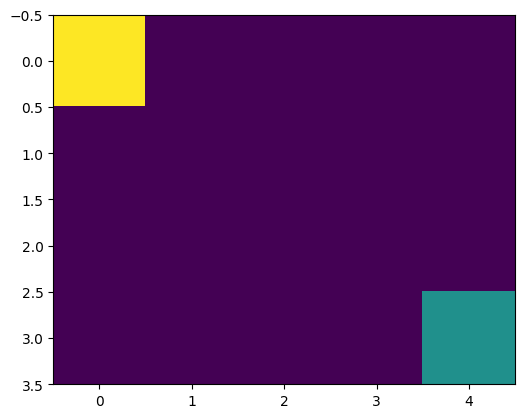

In [3]:
# intial position
pos1=[0,0]
# goal position
pos2=[3,4]

grid[tuple(pos1)]=1
grid[tuple(pos2)]=0.5

plt.imshow(grid)

2. Define an RL environment

In [4]:
class GridEnvironment(gym.Env):

    metadata = {'render.modes': []}

    def __init__(self):
        self.observation_space = spaces.Discrete(20)
        self.action_space = spaces.Discrete(4)

        self.max_timesteps = 100

        # --- Reward map (>=4 reward types) ---
        self.reward_map = {
            "goal": 10,
            "trap": -5,
            "gem": 3,
            "step": -1
        }

        self.agent_pos = [0, 0]
        self.goal_pos = [3, 4]
        self.trap_pos = [2, 2]
        self.gem_pos  = [1, 4]
        self.collected_gem = False



    def reset(self, **kwargs):
        self.timestep = 0
        self.agent_pos = [0, 0]

        self.state = np.zeros((4, 5))
        self.state[tuple(self.agent_pos)] = 1
        self.state[tuple(self.goal_pos)] = 0.8
        self.state[tuple(self.trap_pos)] = 0.2
        self.state[tuple(self.gem_pos)]  = 0.5
        self.collected_gem = False


        return self.state.flatten(), {}

    def step(self, action):

        # DOWN
        if action == 0:
            self.agent_pos[0] += 1

        # UP
        if action == 1:
            self.agent_pos[0] -= 1

        # RIGHT
        if action == 2:
            self.agent_pos[1] += 1

        # LEFT
        if action == 3:
            self.agent_pos[1] -= 1

        # --- FIXED CLIP (grid 4×5) ---
        self.agent_pos = np.clip(self.agent_pos, [0, 0], [3, 4])

        # rebuild state
        self.state = np.zeros((4, 5))
        self.state[tuple(self.goal_pos)] = 0.8
        self.state[tuple(self.trap_pos)] = 0.2
        if not self.collected_gem:
          self.state[tuple(self.gem_pos)] = 0.5
        self.state[tuple(self.agent_pos)] = 1

        observation = self.state.flatten()

        # default step
        reward = self.reward_map["step"]

        if np.array_equal(self.agent_pos, self.goal_pos):
            reward = self.reward_map["goal"]
        elif np.array_equal(self.agent_pos ,self.trap_pos):
            reward = self.reward_map["trap"]
        elif np.array_equal(self.agent_pos, self.gem_pos) and not self.collected_gem:
            reward = self.reward_map["gem"]
            self.collected_gem = True


        self.timestep += 1

        # terminated = (self.timestep >= self.max_timesteps)
        terminated = False
        if np.array_equal(self.agent_pos, self.goal_pos):
          terminated = True
        elif self.timestep >= self.max_timesteps:
          terminated = True
        # no early truncation
        truncated = False

        return observation, reward, terminated, truncated, {},self.agent_pos.copy()

    def render(self):
      plt.title("Grid environment")

    # Make a copy of the internal state for display
      grid = self.state.copy()
      for x in range(6):
        plt.axvline(x - 0.5, color='black', linewidth=1)
      for y in range(5):
        plt.axhline(y - 0.5, color='black', linewidth=1)
      plt.imshow(grid)
      plt.show()

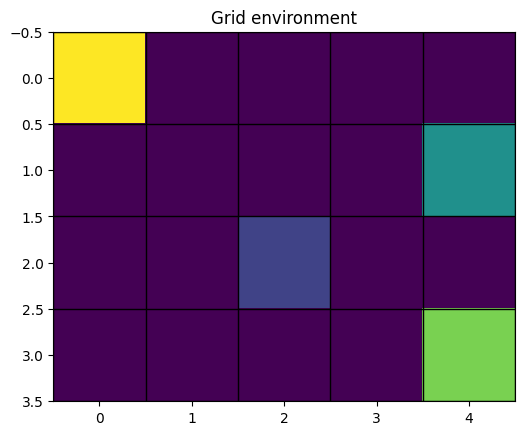

In [5]:
env  = GridEnvironment()
terminated,truncated=False,False
obs,info=env.reset()
env.render()

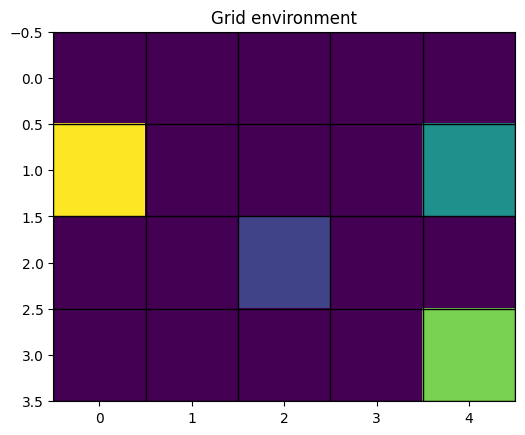

In [6]:
action = 0
observation, reward, terminated, truncated, info,agent_pos = env.step(action)
env.render()

In [7]:
# Definition an agent that takes action randomly
class RandomAgent:

  def __init__(self, env):
    self.env = env
    self.observation_space = env.observation_space
    self.action_space = env.action_space

  def step(self, obs):
    """Takes a step in the environment by choosing an action randomly.

    Args:
        obs: The current observation.

    Returns:
        The action to take.
    """
    return np.random.choice(self.action_space.n)

3. Running the Random Agent for 10 timesteps

Action: 0 Reward: -1 Agent Position: [1 0] Done: False


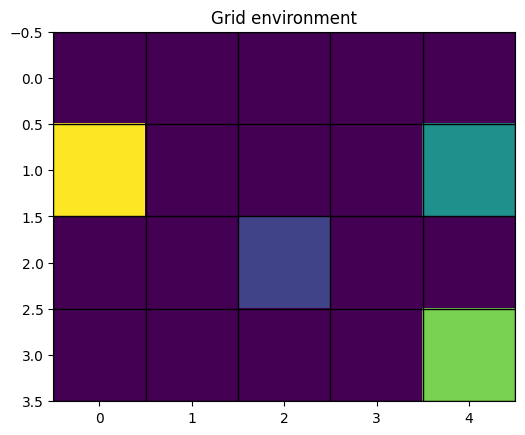

Action: 1 Reward: -1 Agent Position: [0 0] Done: False


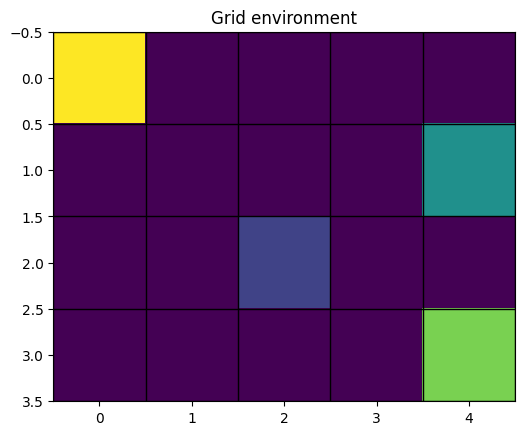

Action: 0 Reward: -1 Agent Position: [1 0] Done: False


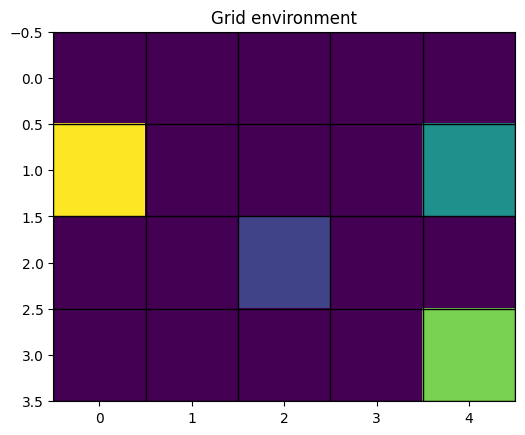

Action: 1 Reward: -1 Agent Position: [0 0] Done: False


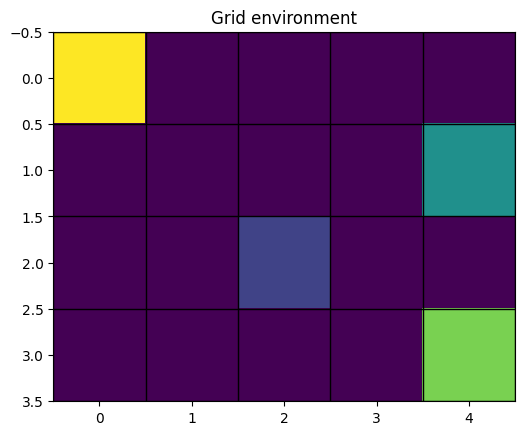

Action: 3 Reward: -1 Agent Position: [0 0] Done: False


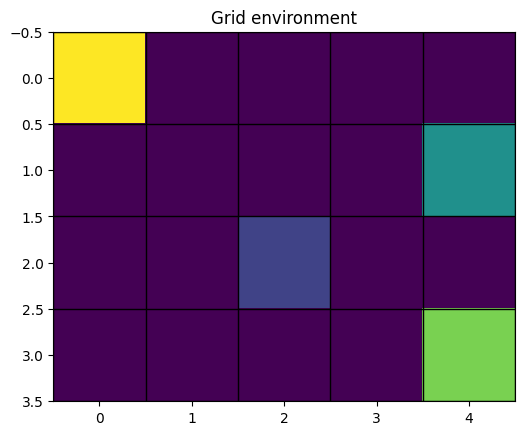

Action: 2 Reward: -1 Agent Position: [0 1] Done: False


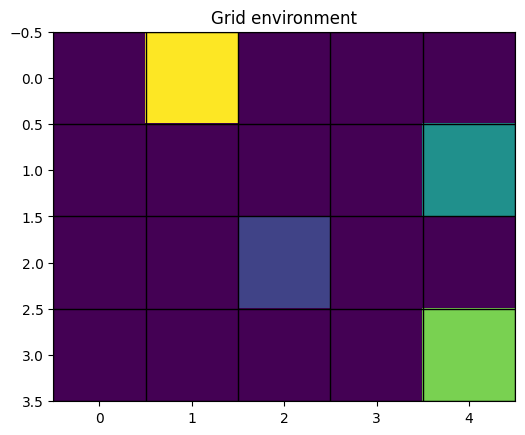

Action: 1 Reward: -1 Agent Position: [0 1] Done: False


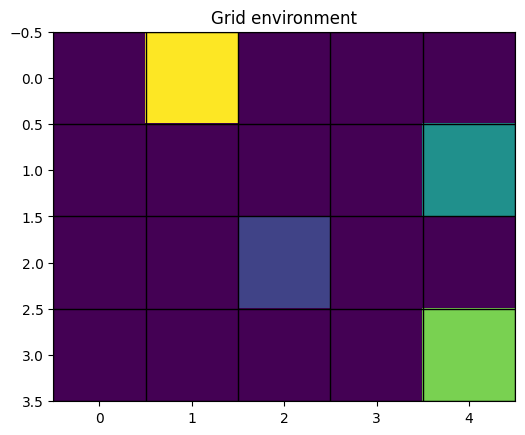

Action: 2 Reward: -1 Agent Position: [0 2] Done: False


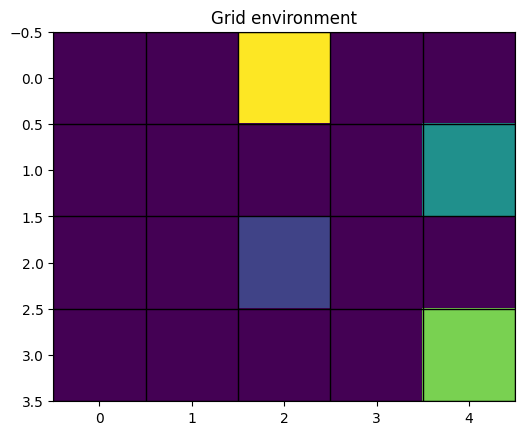

Action: 1 Reward: -1 Agent Position: [0 2] Done: False


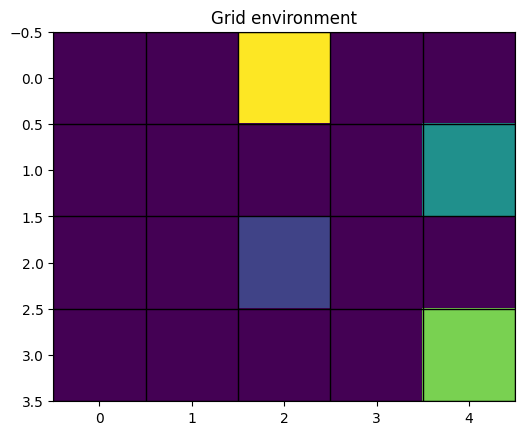

Action: 3 Reward: -1 Agent Position: [0 1] Done: False


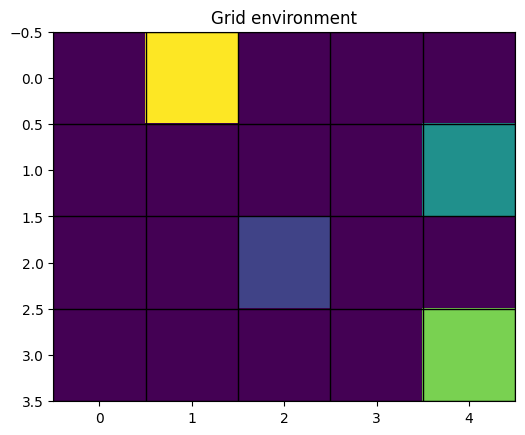

Action: 1 Reward: -1 Agent Position: [0 1] Done: False


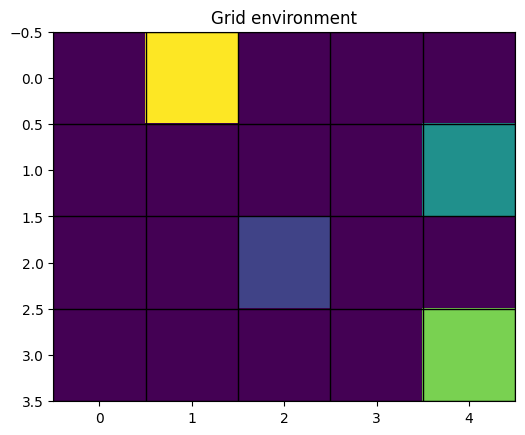

Action: 1 Reward: -1 Agent Position: [0 1] Done: False


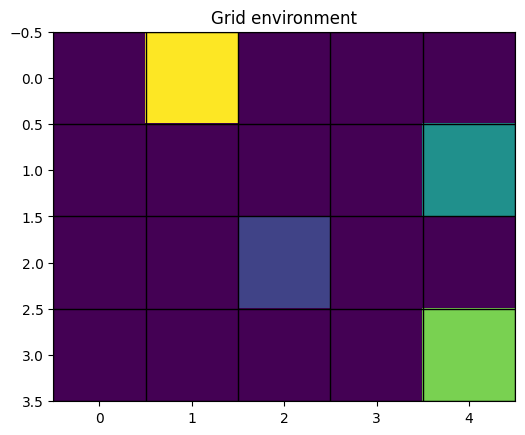

Action: 1 Reward: -1 Agent Position: [0 1] Done: False


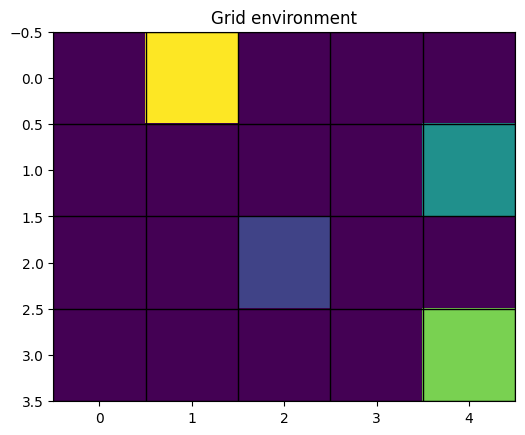

Action: 0 Reward: -1 Agent Position: [1 1] Done: False


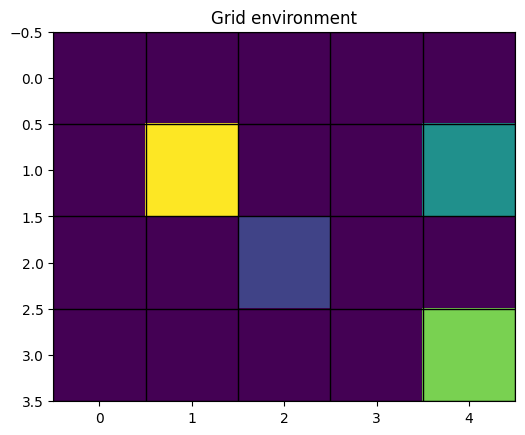

Action: 1 Reward: -1 Agent Position: [0 1] Done: False


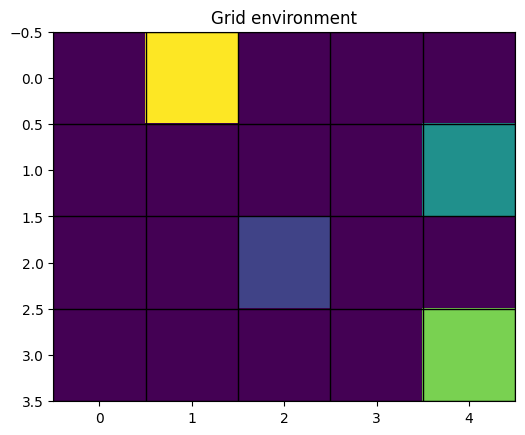

Action: 1 Reward: -1 Agent Position: [0 1] Done: False


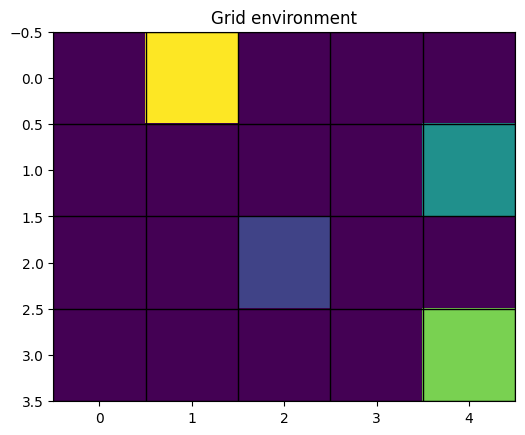

Action: 1 Reward: -1 Agent Position: [0 1] Done: False


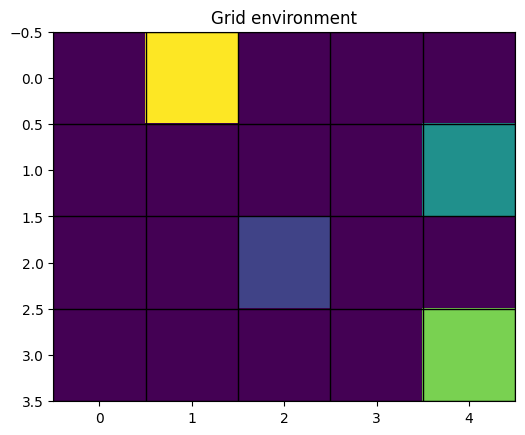

Action: 3 Reward: -1 Agent Position: [0 0] Done: False


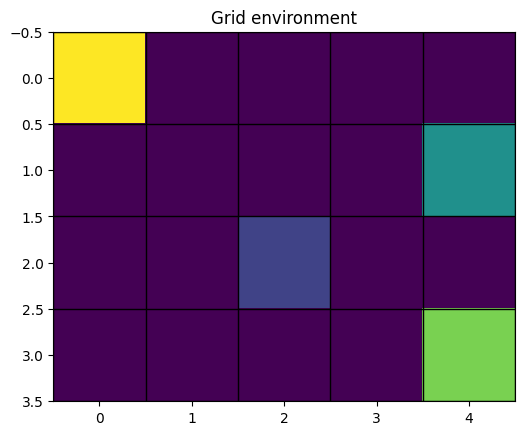

Action: 1 Reward: -1 Agent Position: [0 0] Done: False


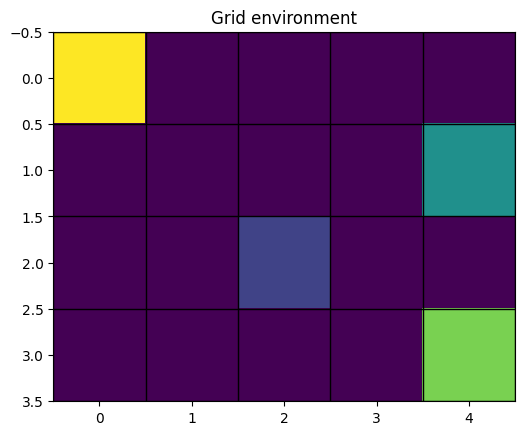

Action: 2 Reward: -1 Agent Position: [0 1] Done: False


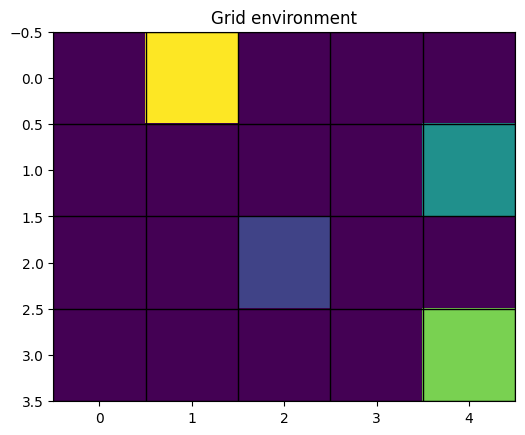

Action: 3 Reward: -1 Agent Position: [0 0] Done: False


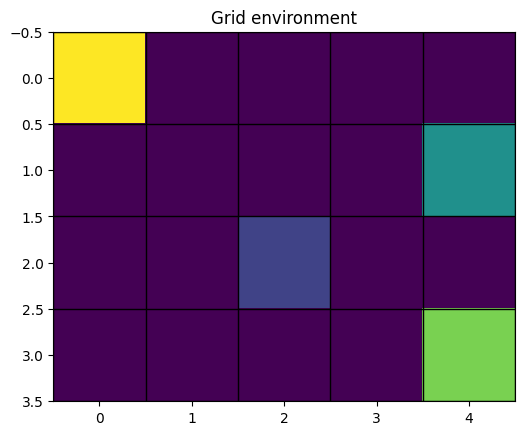

Action: 1 Reward: -1 Agent Position: [0 0] Done: False


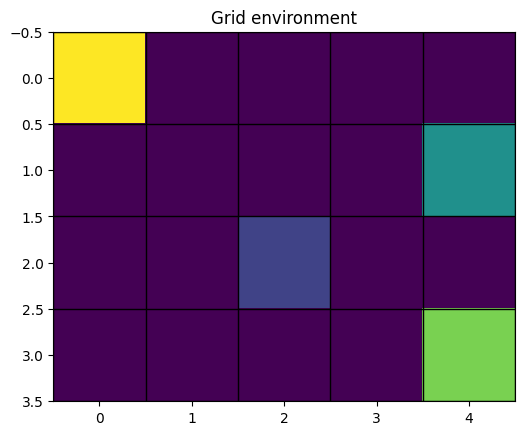

Action: 1 Reward: -1 Agent Position: [0 0] Done: False


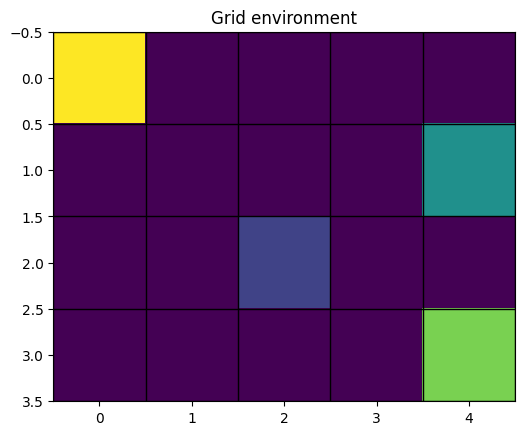

Action: 3 Reward: -1 Agent Position: [0 0] Done: False


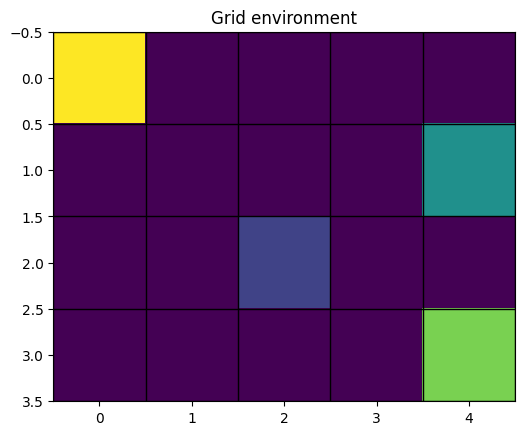

Action: 0 Reward: -1 Agent Position: [1 0] Done: False


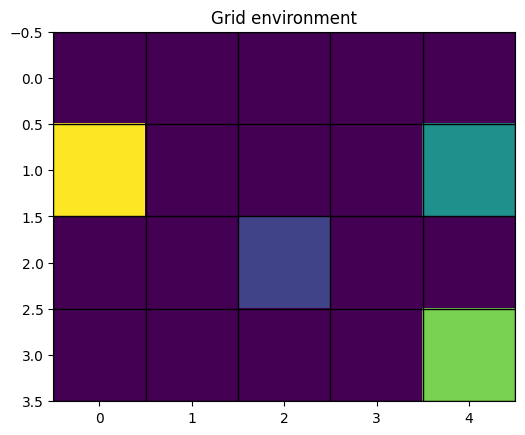

Action: 3 Reward: -1 Agent Position: [1 0] Done: False


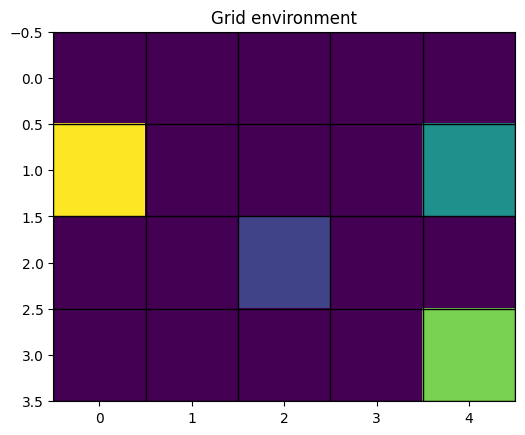

Action: 2 Reward: -1 Agent Position: [1 1] Done: False


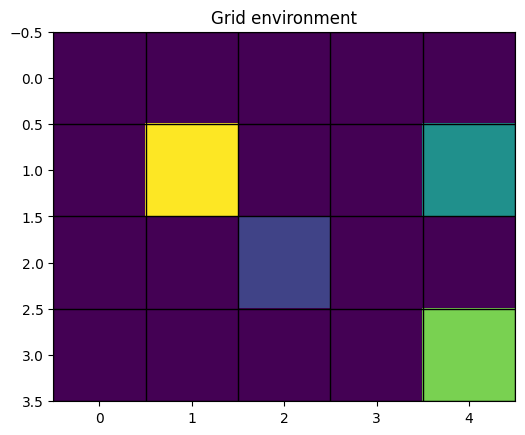

Action: 3 Reward: -1 Agent Position: [1 0] Done: False


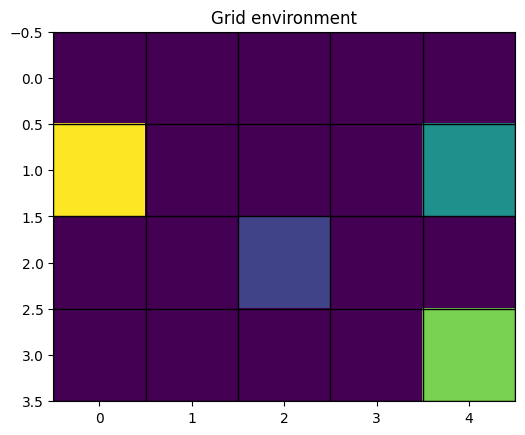

Action: 3 Reward: -1 Agent Position: [1 0] Done: False


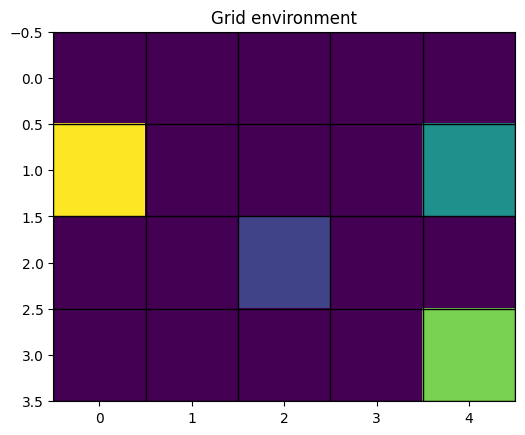

Action: 2 Reward: -1 Agent Position: [1 1] Done: False


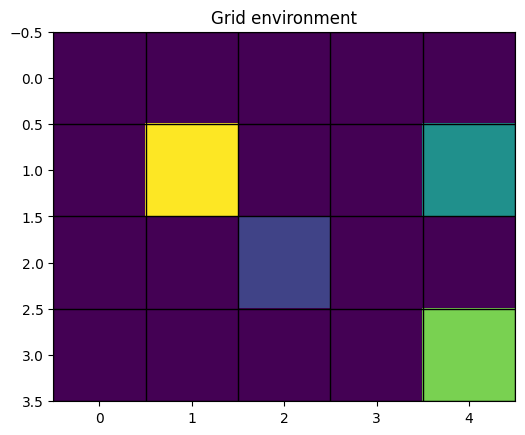

Action: 0 Reward: -1 Agent Position: [2 1] Done: False


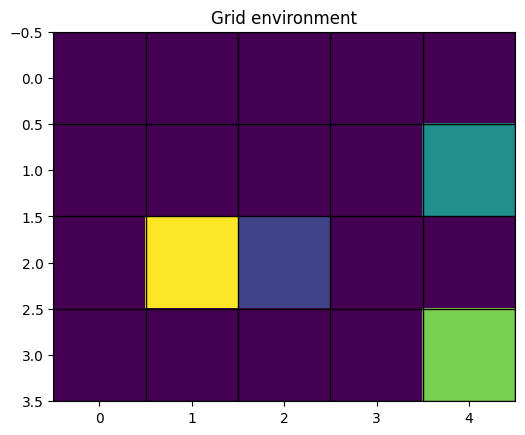

Action: 3 Reward: -1 Agent Position: [2 0] Done: False


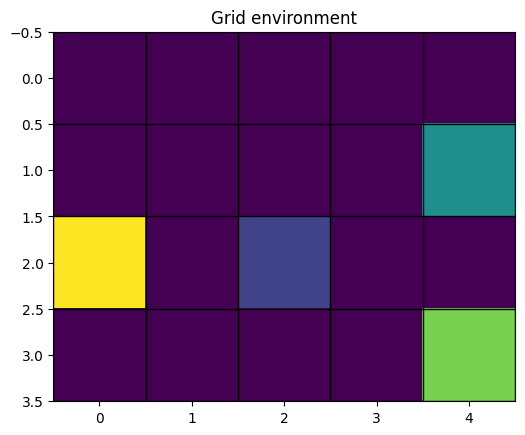

Action: 0 Reward: -1 Agent Position: [3 0] Done: False


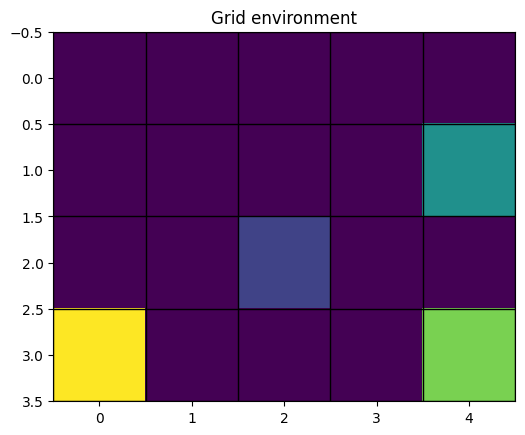

Action: 3 Reward: -1 Agent Position: [3 0] Done: False


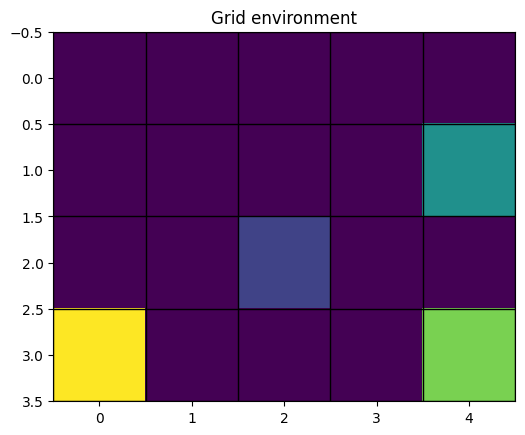

Action: 0 Reward: -1 Agent Position: [3 0] Done: False


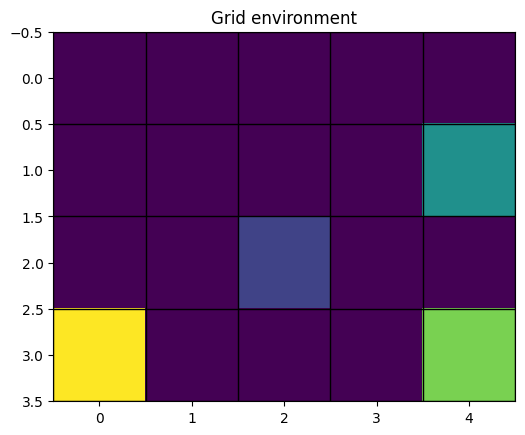

Action: 1 Reward: -1 Agent Position: [2 0] Done: False


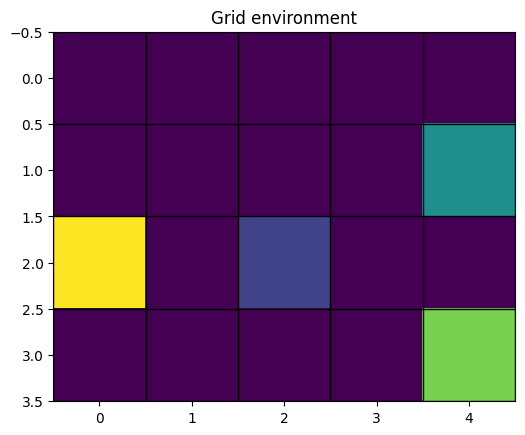

Action: 2 Reward: -1 Agent Position: [2 1] Done: False


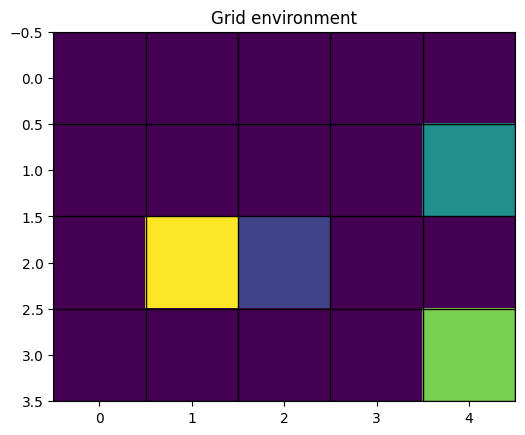

Action: 2 Reward: -5 Agent Position: [2 2] Done: False


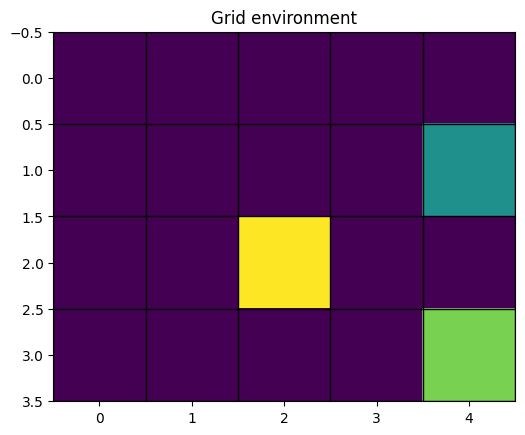

Action: 0 Reward: -1 Agent Position: [3 2] Done: False


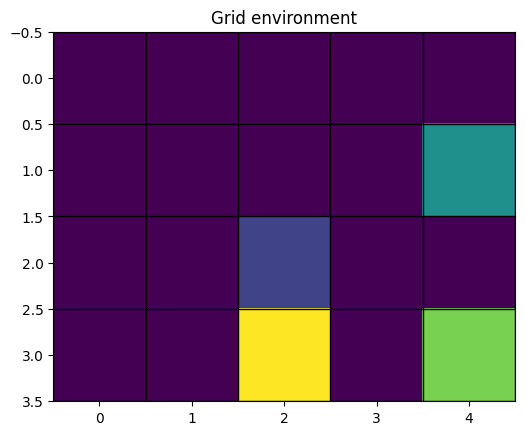

Action: 2 Reward: -1 Agent Position: [3 3] Done: False


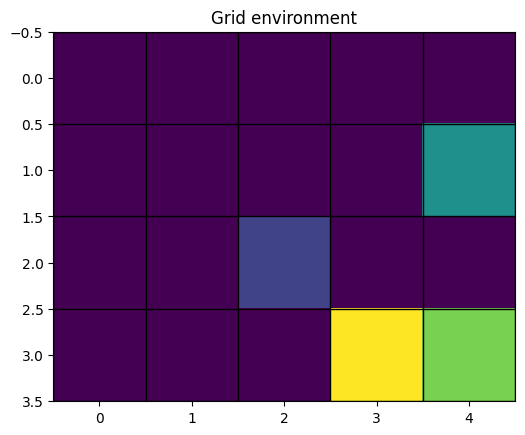

Action: 1 Reward: -1 Agent Position: [2 3] Done: False


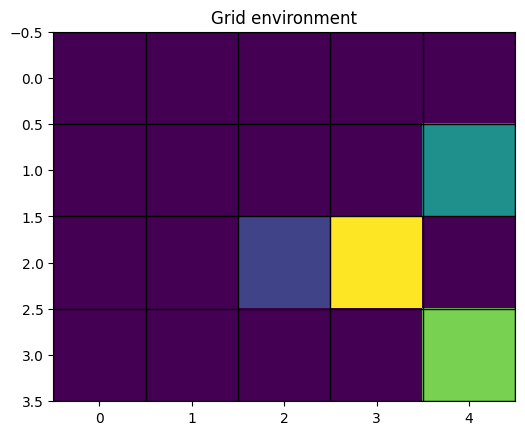

Action: 1 Reward: -1 Agent Position: [1 3] Done: False


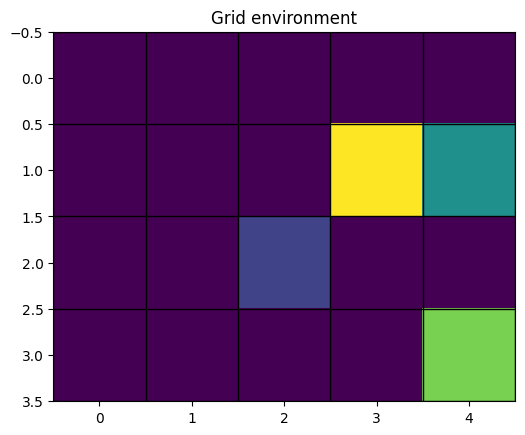

Action: 3 Reward: -1 Agent Position: [1 2] Done: False


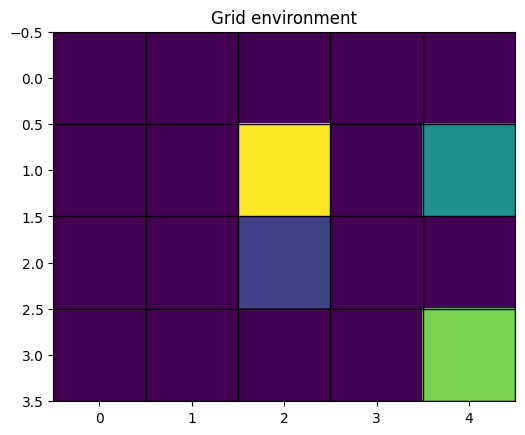

Action: 0 Reward: -5 Agent Position: [2 2] Done: False


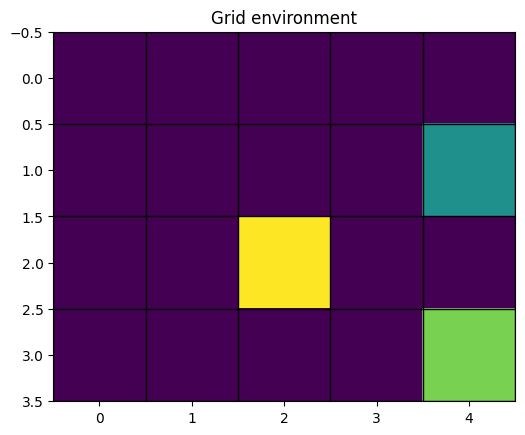

Action: 1 Reward: -1 Agent Position: [1 2] Done: False


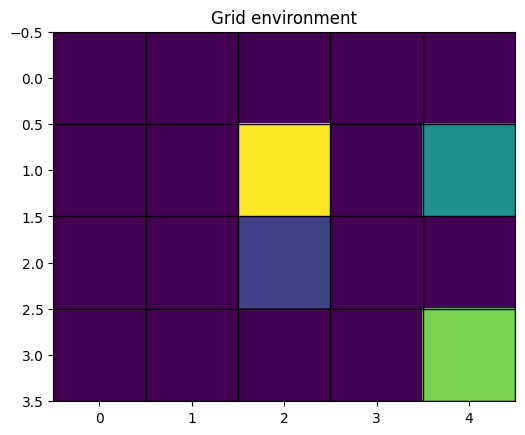

Action: 2 Reward: -1 Agent Position: [1 3] Done: False


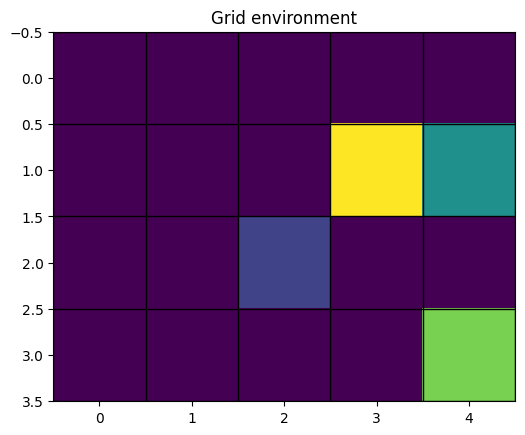

Action: 1 Reward: -1 Agent Position: [0 3] Done: False


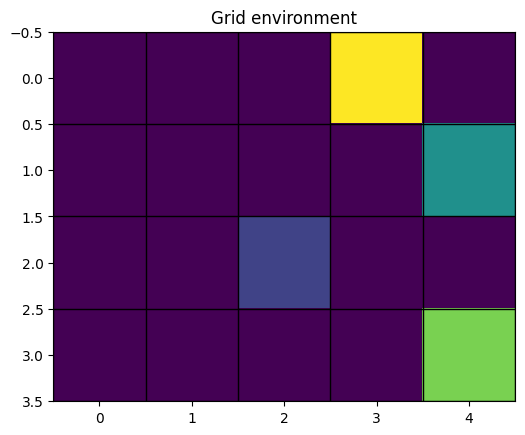

Action: 1 Reward: -1 Agent Position: [0 3] Done: False


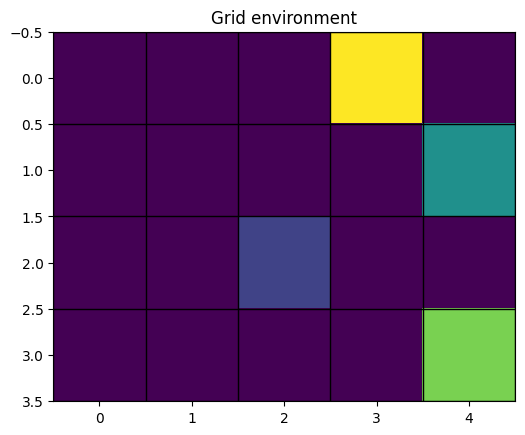

Action: 1 Reward: -1 Agent Position: [0 3] Done: False


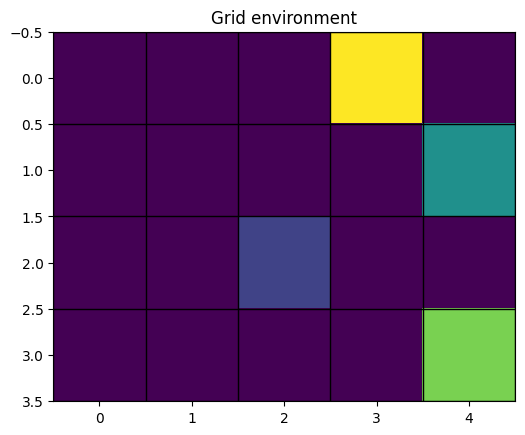

Action: 1 Reward: -1 Agent Position: [0 3] Done: False


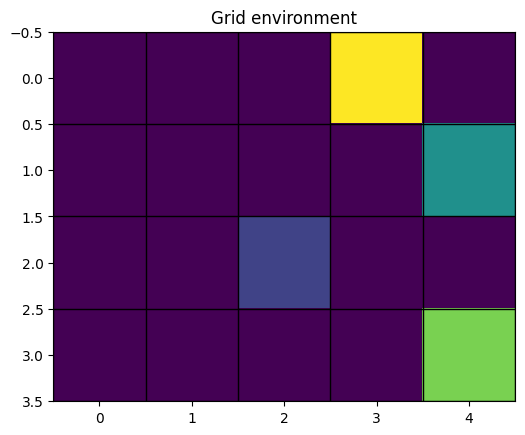

Action: 3 Reward: -1 Agent Position: [0 2] Done: False


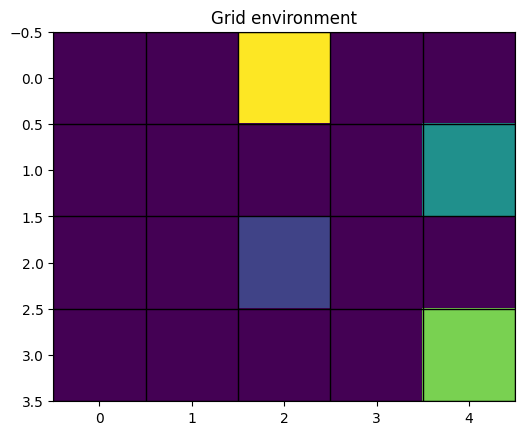

Action: 3 Reward: -1 Agent Position: [0 1] Done: False


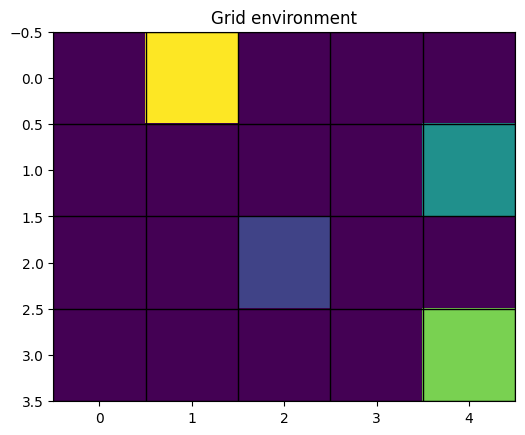

Action: 2 Reward: -1 Agent Position: [0 2] Done: False


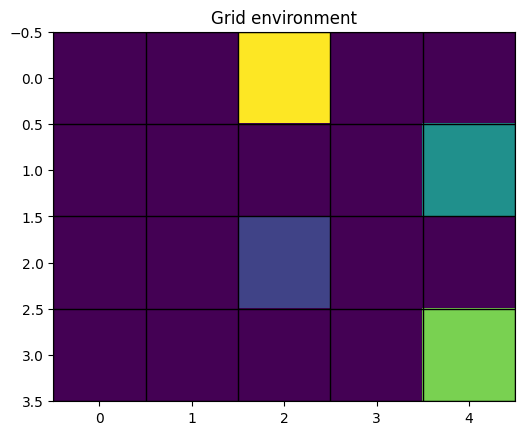

Action: 3 Reward: -1 Agent Position: [0 1] Done: False


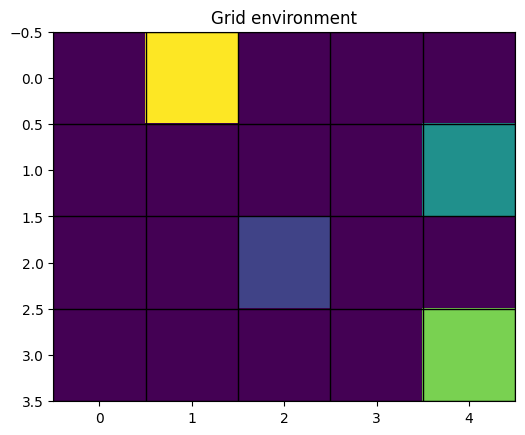

Action: 2 Reward: -1 Agent Position: [0 2] Done: False


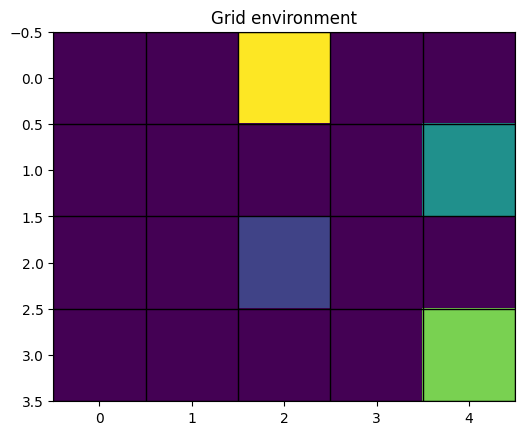

Action: 2 Reward: -1 Agent Position: [0 3] Done: False


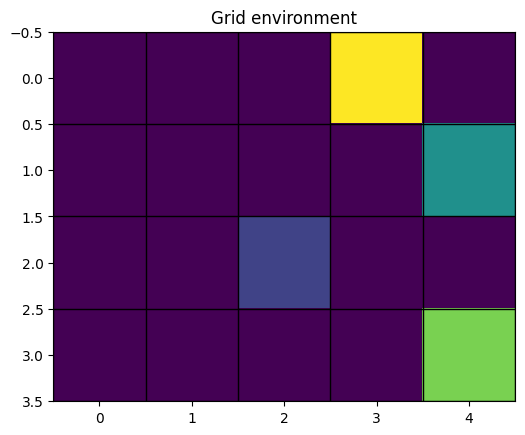

Action: 3 Reward: -1 Agent Position: [0 2] Done: False


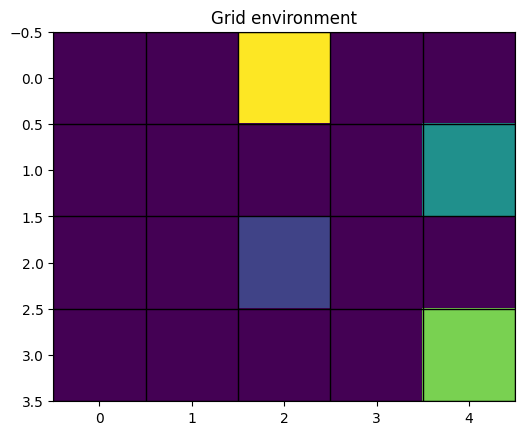

Action: 1 Reward: -1 Agent Position: [0 2] Done: False


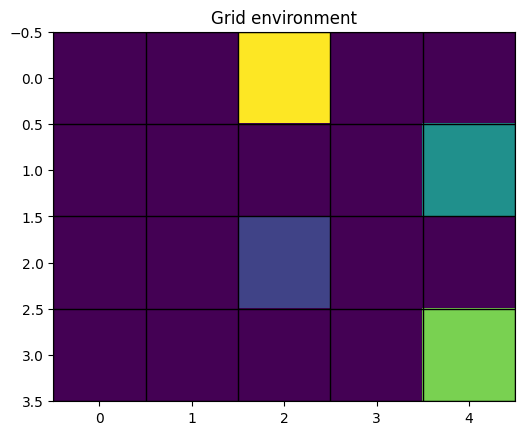

Action: 0 Reward: -1 Agent Position: [1 2] Done: False


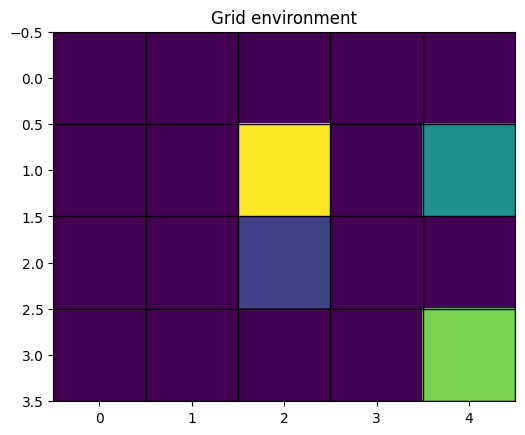

Action: 1 Reward: -1 Agent Position: [0 2] Done: False


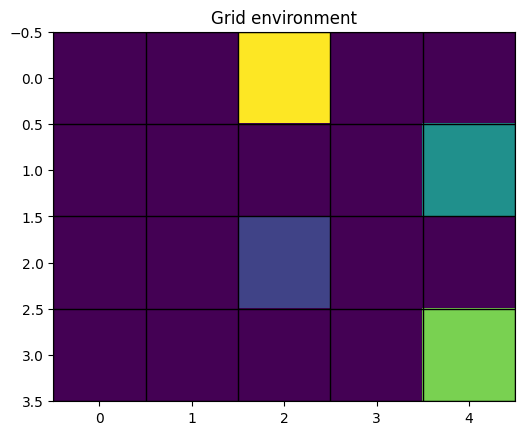

Action: 0 Reward: -1 Agent Position: [1 2] Done: False


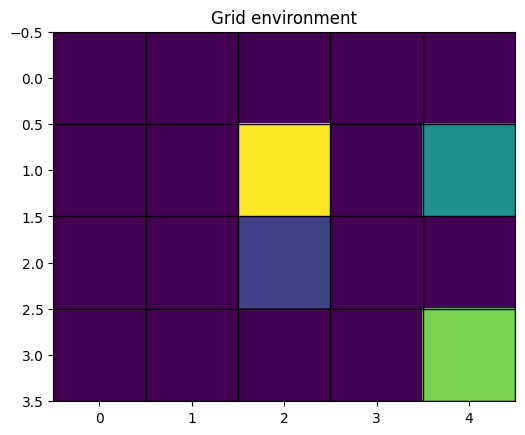

Action: 0 Reward: -5 Agent Position: [2 2] Done: False


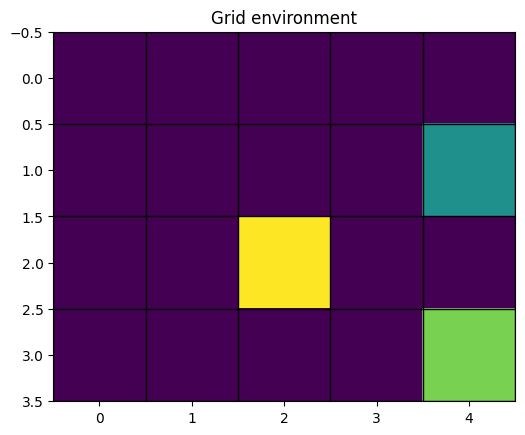

Action: 0 Reward: -1 Agent Position: [3 2] Done: False


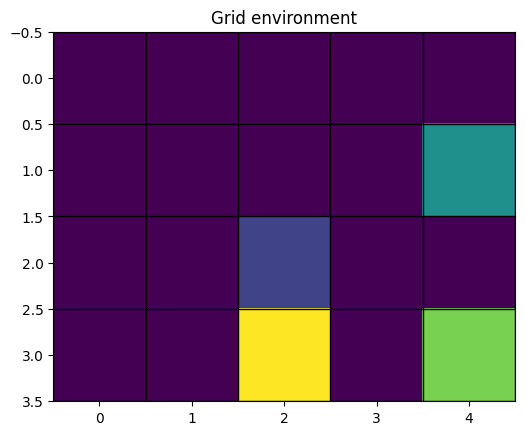

Action: 0 Reward: -1 Agent Position: [3 2] Done: False


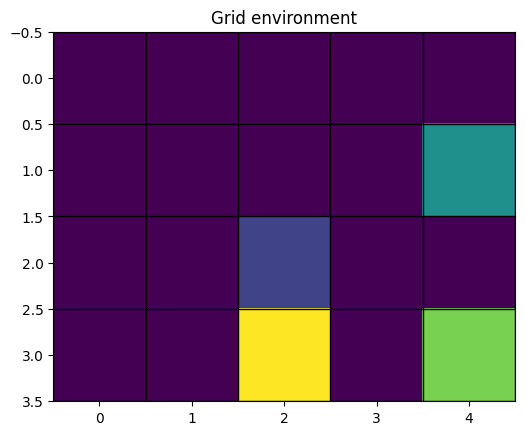

Action: 0 Reward: -1 Agent Position: [3 2] Done: False


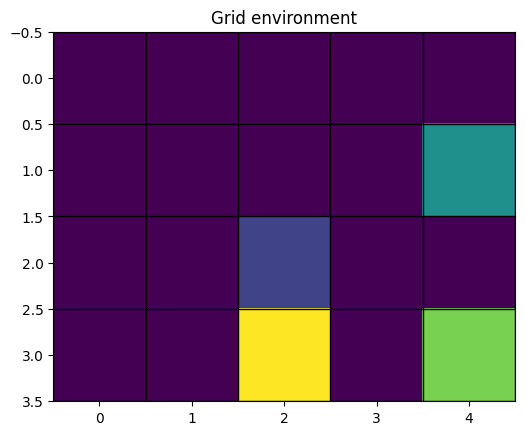

Action: 1 Reward: -5 Agent Position: [2 2] Done: False


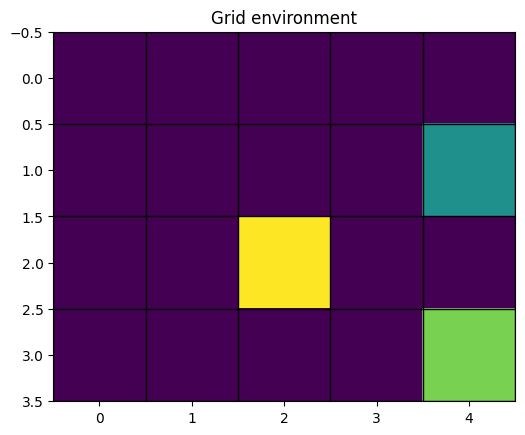

Action: 3 Reward: -1 Agent Position: [2 1] Done: False


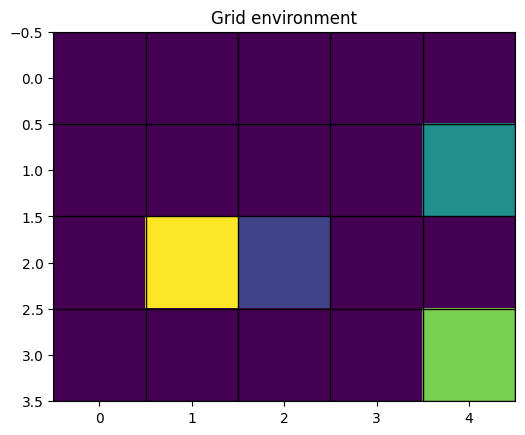

Action: 2 Reward: -5 Agent Position: [2 2] Done: False


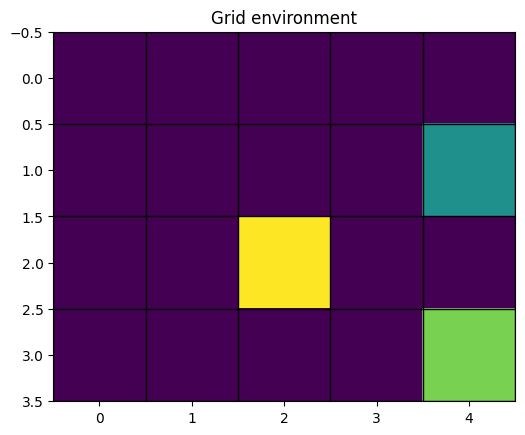

Action: 3 Reward: -1 Agent Position: [2 1] Done: False


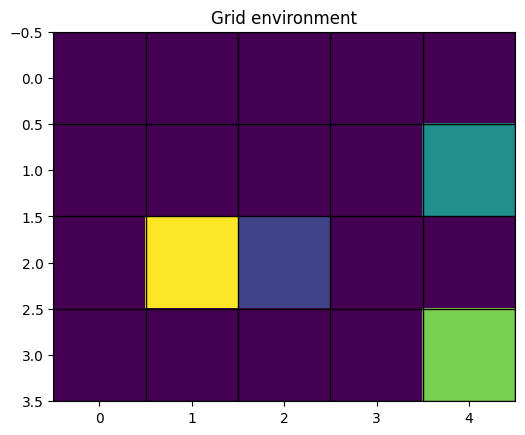

Action: 3 Reward: -1 Agent Position: [2 0] Done: False


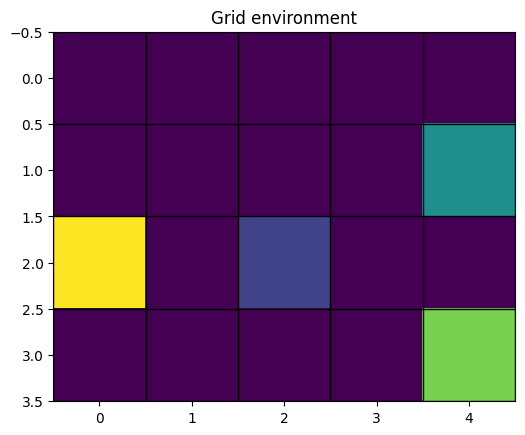

Action: 2 Reward: -1 Agent Position: [2 1] Done: False


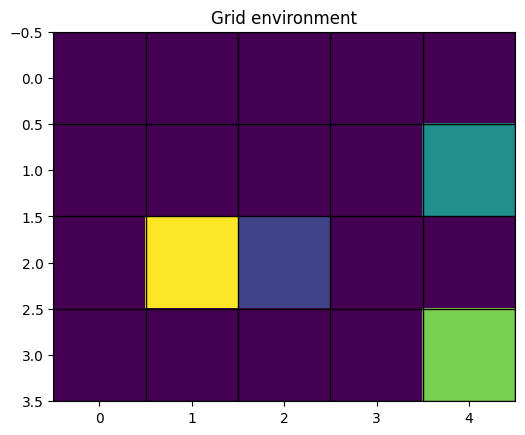

Action: 2 Reward: -5 Agent Position: [2 2] Done: False


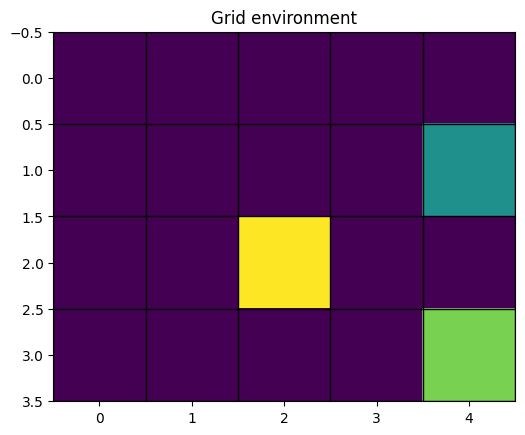

Action: 2 Reward: -1 Agent Position: [2 3] Done: False


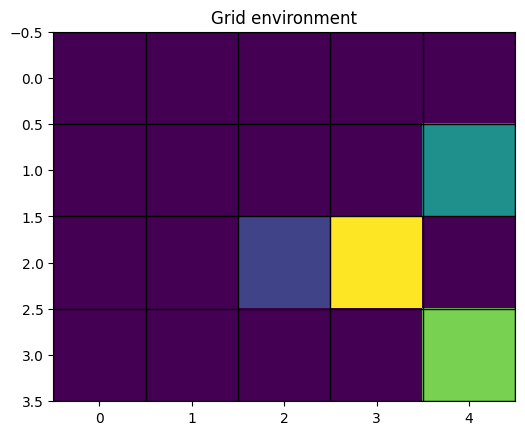

Action: 3 Reward: -5 Agent Position: [2 2] Done: False


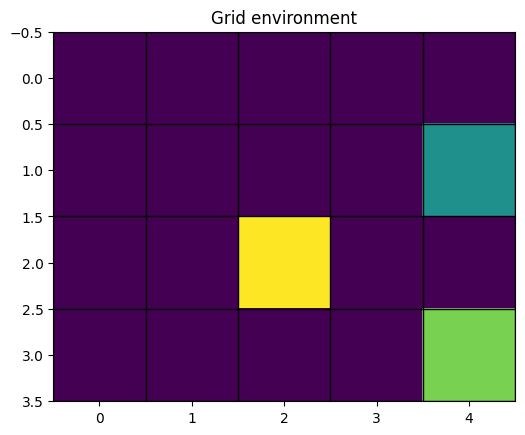

Action: 3 Reward: -1 Agent Position: [2 1] Done: False


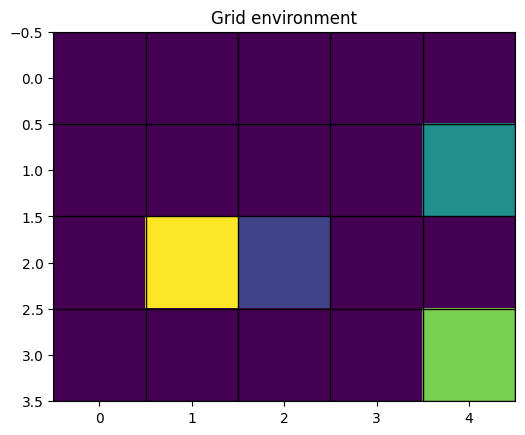

Action: 3 Reward: -1 Agent Position: [2 0] Done: False


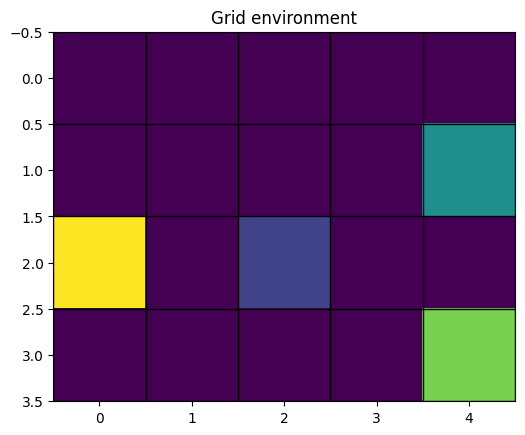

Action: 2 Reward: -1 Agent Position: [2 1] Done: False


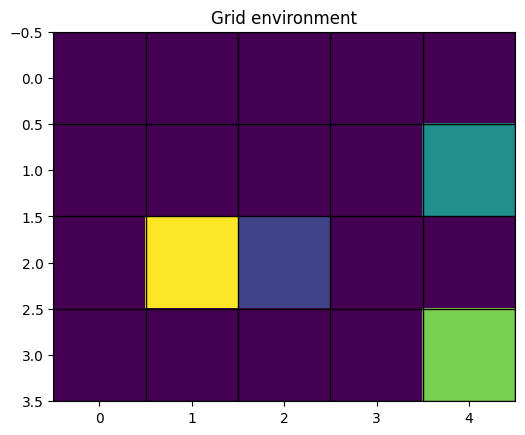

Action: 0 Reward: -1 Agent Position: [3 1] Done: False


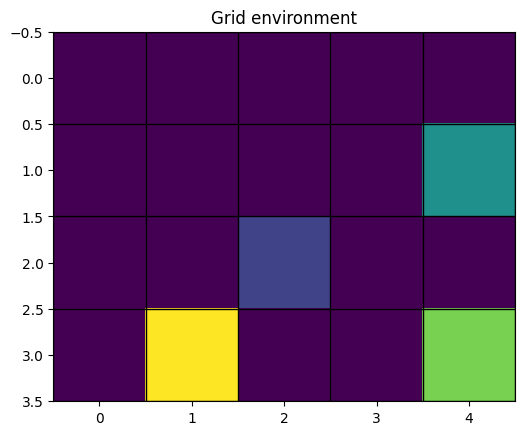

Action: 2 Reward: -1 Agent Position: [3 2] Done: False


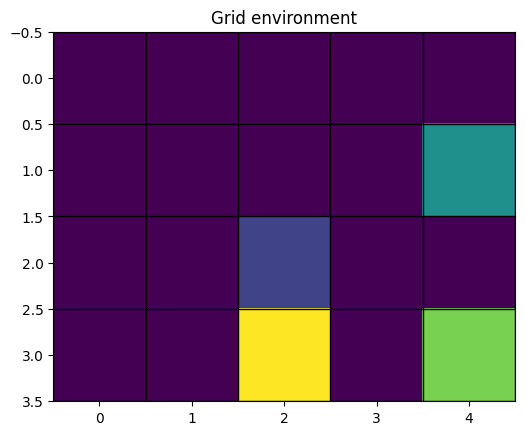

Action: 2 Reward: -1 Agent Position: [3 3] Done: False


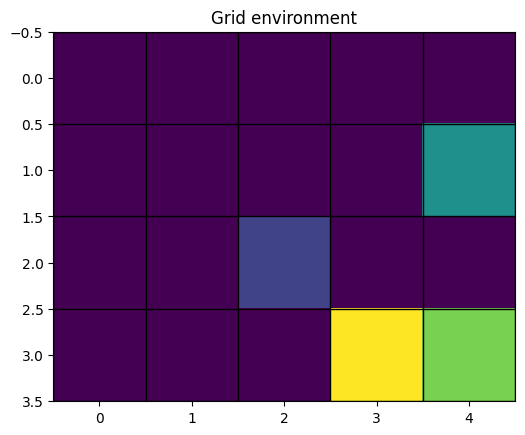

Action: 1 Reward: -1 Agent Position: [2 3] Done: False


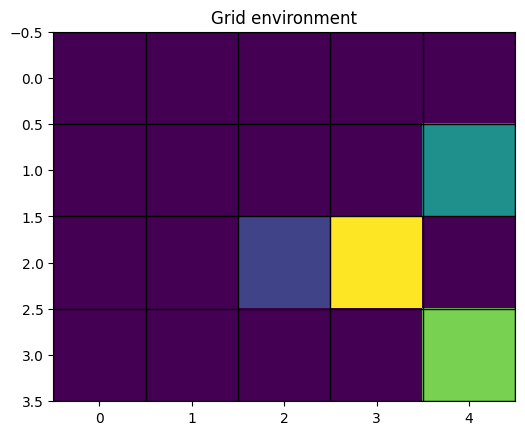

Action: 0 Reward: -1 Agent Position: [3 3] Done: False


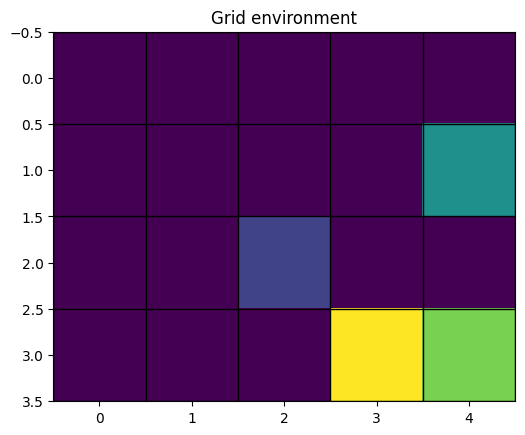

Action: 2 Reward: 10 Agent Position: [3 4] Done: True


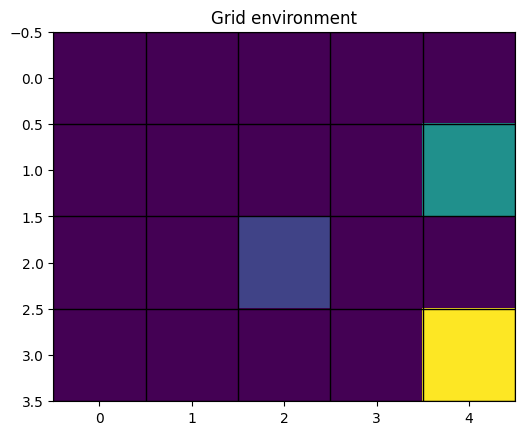

In [8]:
if __name__ == "__main__":
  env = GridEnvironment()
  agent = RandomAgent(env)
  obs,info = env.reset()
  terminated,truncated=False,False
  while not terminated:
    # action will be given by random agent
    action = agent.step(obs)
    # after getting the action we will pass it into the environment
    obs,reward,terminated,truncated,info,agent_pos = env.step(action)

    print('Action:',action,'Reward:',reward,'Agent Position:',agent_pos,'Done:',terminated)
    env.render()

4. Environment Description

The enviornment is simple grid based Reinforcment learning enviornment which is designed using the OpenAI Gym package. Its a 4x5 grid world where the task of the agent is to navigate the path to reach the goal state, avoding the traps and collecting the rewards where ever it available.

a. The environment has 20 discreate states, each state is represents unique position of agent in the grid.

     1.0 indicates the agent's current position.

     0.8 indicates the goal position.

     0.5 indicates a gem (bonus reward).

     0.2 indicates a trap.

b. ACTIONS --> Agent can perform 4 actions i.e
  
    0 - DOWN, 1 - UP , 2 - RIGHT ,  3 - LEFT

    Agent movement is clipped inside the (4x5) grid

c.  Rewards --> In our environment we have defined four types of rewards

    Step --> +1
    Reach Goal --> +10
    Trap --> -5
    Gem --> +3

d. In the reset method we are reseating the gem value back to false once per episode so that we are not counting the same gem again during the same episode.



5. visualization of our environment

In [9]:
env = GridEnvironment()
agent = RandomAgent(env)
num_episodes = 150
epsilon_start = 1.0
epsilon_min = 0.1
epsilon_decay = 0.95

# Tracking variables
all_episode_rewards = []
all_steps = []
successes = []

epsilon = epsilon_start

for ep in range(num_episodes):
  obs,info = env.reset()
  total_reward = 0
  steps = 0
  reached_goal = False

  for t in range(env.max_timesteps):
      # Epislon greedy action
      if np.random.rand() < epsilon:
          #action = np.random.choice(obs) #Commenting this code (Ritik)
          action  = np.random.choice(env.action_space.n)
      else:
          # Exploitation: move greedily toward the goal
          agent_pos = np.array(env.agent_pos)
          goal_pos  = np.array(env.goal_pos)
          diff = goal_pos - agent_pos
          # diff[0] > 0 → goal is below the agent → move DOWN (action=0)
          # diff[0] < 0 → goal is above the agent → move UP (action=1)
          # diff[1] > 0 → goal is to the right → move RIGHT (action=2)
          # diff[1] < 0 → goal is to the left → move LEFT (action=3)
          if abs(diff[0]) > abs(diff[1]):
            action = 0 if diff[0] > 0 else 1
          else:
            action = 2 if diff[1] > 0 else 3
      obs, reward, terminated, truncated, info, agent_pos = env.step(action)
      total_reward += reward
      steps += 1
      if np.array_equal(agent_pos, env.goal_pos):
            reached_goal = True
      if terminated:
            break
  # Store metrics
  all_episode_rewards.append(total_reward)
  all_steps.append(steps)
  successes.append(reached_goal)

  epsilon = max(epsilon_min, epsilon * epsilon_decay)

success_rate = np.cumsum(successes) / np.arange(1, num_episodes+1) * 100

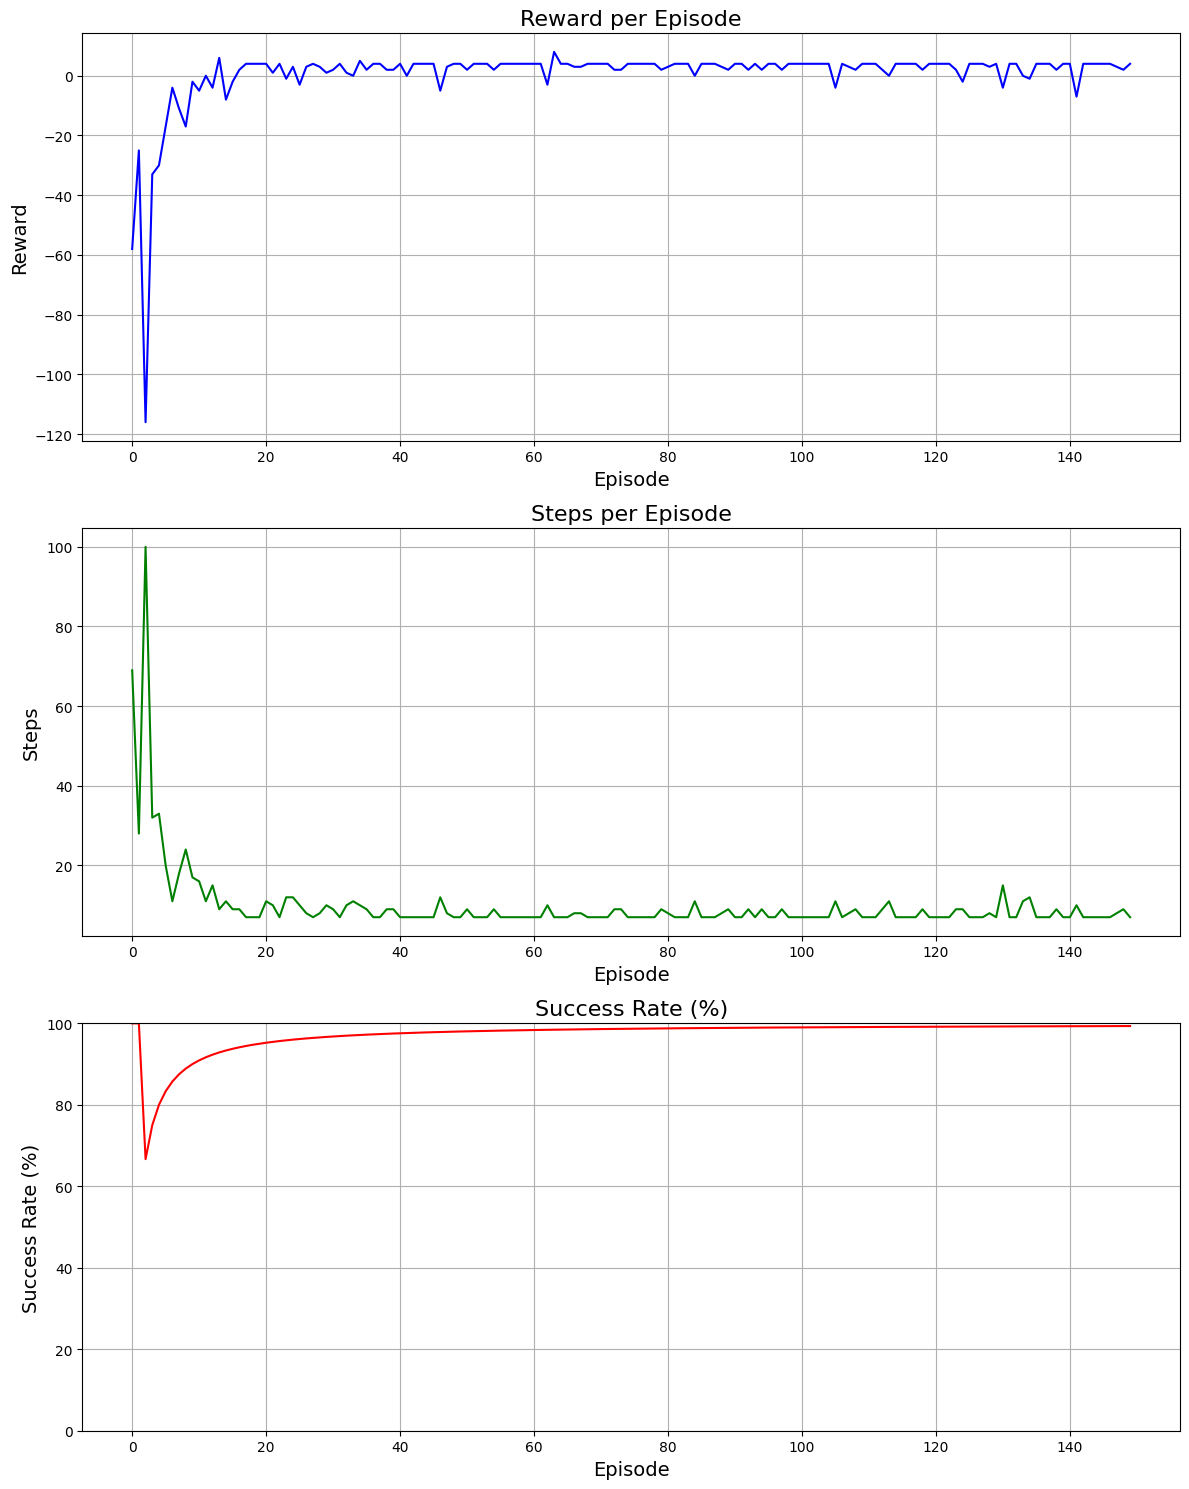

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

# 1. Reward per episode
axs[0].plot(all_episode_rewards, color='blue')
axs[0].set_title('Reward per Episode', fontsize=16)
axs[0].set_xlabel('Episode', fontsize=14)
axs[0].set_ylabel('Reward', fontsize=14)
axs[0].grid(True)

# 2. Steps per episode
axs[1].plot(all_steps, color='green')
axs[1].set_title('Steps per Episode', fontsize=16)
axs[1].set_xlabel('Episode', fontsize=14)
axs[1].set_ylabel('Steps', fontsize=14)
axs[1].grid(True)

# 3. Success rate
axs[2].plot(success_rate, color='red')
axs[2].set_title('Success Rate (%)', fontsize=16)
axs[2].set_xlabel('Episode', fontsize=14)
axs[2].set_ylabel('Success Rate (%)', fontsize=14)
axs[2].set_ylim(0, 100)
axs[2].grid(True)

plt.tight_layout()
plt.show()

Safety in AI: A brief review

1. The agent is allowed to perform only 4 set of actions
i.e [0, 1, 2, 3] (DOWN, UP, RIGHT, LEFT).

2. The state space is limited to (4x5) grid and agent position is clipped so that it stays within the boundry.

3. Rewards are also Mapped to location such as gem, trap or goal avoding undefined or unexpected results.

4. In our environment we have defined the maximum number of timesteps, ensuring episodes termiate safely.

5. The agent learning is contolled by clear objective and controlled reward signals.


Part 2


Implement the SARSA algorithm to solve the environment defined in Part I.

In [22]:
env = GridEnvironment()
#agent = RandomAgent(env)
num_episodes = 150
epsilon_start = 1.0
epsilon_min = 0.1
epsilon_decay = 0.95
alpha = 0.1
gamma = 0.99

# Tracking variables
all_episode_rewards = []
epsilon_values = []
successes = []

#Inital Q value while starting SARSA

state_size = env.observation_space.n  #Showing values of the states from 0-19
action_size = env.action_space.n #Showing values of the states from 0-3

print('State size: ',state_size)
print('Action size: ',action_size)

Q = np.zeros((env.observation_space.n, env.action_space.n))
print('Inital value of Q table: \n',Q)



epsilon = epsilon_start

def epsilon_greedy_policy(state, epsilon):
    if np.random.rand() < epsilon:
        print
        return np.random.choice(env.action_space.n)
    else:
        return np.argmax(Q[state])


for ep in range(num_episodes):
  obs,info = env.reset()
  total_reward = 0
  steps = 0
  reached_goal = False

  state = env.agent_pos[0] * 5 + env.agent_pos[1]
  action = epsilon_greedy_policy(state, epsilon)



  for t in range(env.max_timesteps):
      next_obs, reward, terminated, truncated, info, agent_pos = env.step(action)
      next_state = agent_pos[0] * 5 + agent_pos[1]
      next_action = epsilon_greedy_policy(next_state, epsilon)

      Q[state, action] += alpha * (reward + gamma * Q[next_state, next_action] - Q[state,action])

      state = next_state
      action = next_action

      total_reward += reward
      if np.array_equal(agent_pos, env.goal_pos):
          reached_goal = True
      if terminated:
            break
  # Store metrics
  all_episode_rewards.append(total_reward)
  epsilon_values.append(epsilon)
  successes.append(reached_goal)

  epsilon = max(epsilon_min, epsilon * epsilon_decay)


print('\nQ table after training \n: ',Q)

State size:  20
Action size:  4
Inital value of Q table: 
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Q table after training 
:  [[-2.16318874 -2.46020048  3.090906   -1.45739915]
 [ 4.23764539 -0.37239344 -1.92818313 -1.02366859]
 [-1.5047004  -1.30409693 -0.85714707 -1.31986742]
 [ 2.55212374 -0.70870321 -0.5692622  -0.69320445]
 [ 3.07674592 -0.3894889  -0.28777318 -0.57792672]
 [-2.03848119 -2.019303    1.12439334 -2.04580017]
 [-1.58264627 -1.38593623  5.46679712 -1.70248771]
 [-4.04005971 -0.87356639  8.32189864  1.38176902]
 [-0.43141075 -0.40698737  9.49092436  2.35724745]
 [ 8.61441733  0.08305037  3.07903065  2.41801375]
 [-1.72571951 -1.76204383 -1.72877858 -1.80973971]
 [-1.13714269  0.21602877 -4.24770249 -1.07799365]


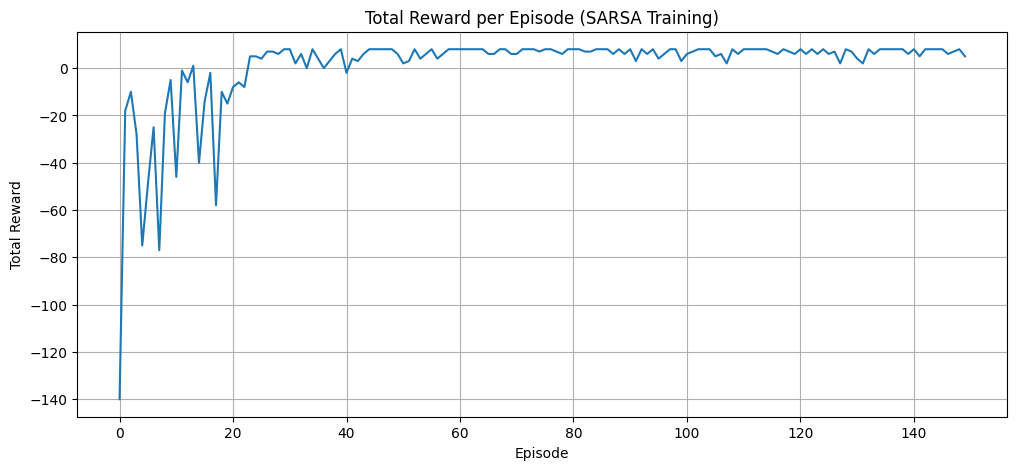

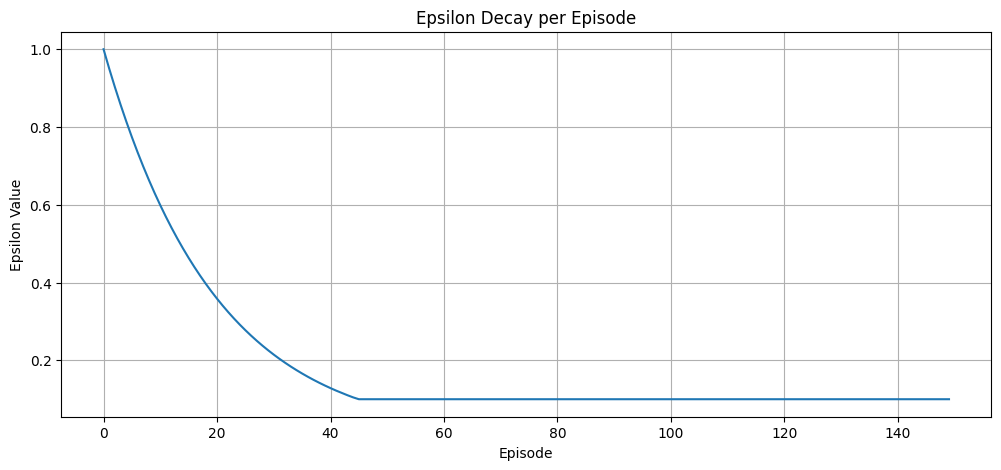

In [23]:
# --- Plot total reward per episode ---
plt.figure(figsize=(12,5))
plt.plot(all_episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode (SARSA Training)")
plt.grid()
plt.show()

# --- Plot epsilon decay ---
plt.figure(figsize=(12,5))
plt.plot(epsilon_values)
plt.xlabel("Episode")
plt.ylabel("Epsilon Value")
plt.title("Epsilon Decay per Episode")
plt.grid()
plt.show()


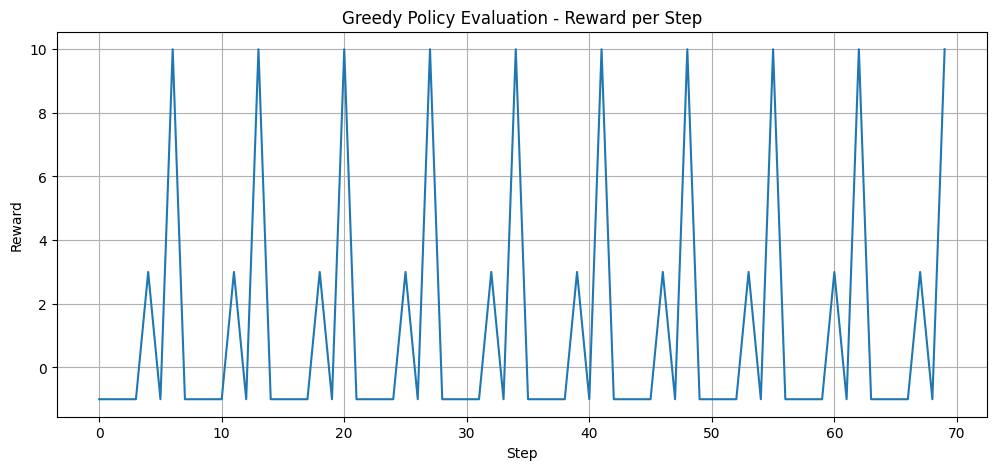

In [26]:
#Evaluaiton of the model
# Tracking variables
greedy_policy_rewards = []
num_episodes = 10
reward_list = []

for ep in range(num_episodes):
    obs, info = env.reset()
    state = env.agent_pos[0] * 5 + env.agent_pos[1]  # get current state index
    total_reward = 0

    for t in range(env.max_timesteps):
        action = np.argmax(Q[state])  # greedy action

        next_obs, reward, terminated, truncated, info, agent_pos = env.step(action)
        next_state = agent_pos[0] * 5 + agent_pos[1]
        state = next_state

        total_reward += reward
        reward_list.append(reward)


        #print(f"Reward: {reward}, Agent Position: {agent_pos}")

        if terminated:
            break

    greedy_policy_rewards.append(total_reward)

# Plot reward over time
plt.figure(figsize=(12,5))
plt.plot(reward_list)
plt.xlabel("Step")
plt.ylabel("Reward")
plt.title("Greedy Policy Evaluation - Reward per Step")
plt.grid()
plt.show()


Hyperparemeter tuning


In [35]:
#based on gamma values
gamma_list = [0.90, 0.001, 0.02]
Q_tables = {}
num_episodes = 150
epsilon_start = 1.0
epsilon_min = 0.1
epsilon_decay = 0.95
alpha = 0.1

for current_gamma_val in gamma_list:
    print(f"\nTraining with gamma = {current_gamma_val}")

    env = GridEnvironment()  # Reset environment
    Q = np.zeros((env.observation_space.n, env.action_space.n))  # Reset Q-table
    print(Q)
    epsilon = epsilon_start

    def epsilon_greedy_policy(state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.choice(env.action_space.n)
        else:
            return np.argmax(Q[state])

    for ep in range(num_episodes):
        obs, info = env.reset()
        total_reward = 0
        reached_goal = False

        state = env.agent_pos[0] * 5 + env.agent_pos[1]
        action = epsilon_greedy_policy(state, epsilon)

        for t in range(env.max_timesteps):
            next_obs, reward, terminated, truncated, info, agent_pos = env.step(action)
            next_state = agent_pos[0] * 5 + agent_pos[1]  # use agent_pos as to now get the value from where the agent is present
            next_action = epsilon_greedy_policy(next_state, epsilon)

            # SARSA update with current gamma
            Q[state, action] += alpha * (reward + current_gamma_val * Q[next_state, next_action] - Q[state, action])

            state = next_state
            action = next_action

            total_reward += reward
            if np.array_equal(agent_pos, env.goal_pos):
                reached_goal = True
            if terminated:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
    #storing the values of Q in dictionary
    Q_tables[current_gamma_val] = Q.copy()

    # Print Q-table after training for current gamma
    print(f"\nQ-table after training with gamma={current_gamma_val}:\n", Q)



Training with gamma = 0.9
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Q-table after training with gamma=0.9:
 [[-2.19849514e+00 -2.09356528e+00  5.14906618e-01 -2.43404644e+00]
 [ 2.10738493e+00 -1.13109689e+00 -1.72180951e+00 -1.92115455e+00]
 [-1.31387826e+00 -1.31609663e+00 -8.08162189e-02 -1.25653099e+00]
 [ 4.28193941e+00 -6.60145955e-01 -6.82202564e-01 -9.96761635e-01]
 [ 2.23939744e+00 -2.58800408e-01 -4.06850944e-01 -5.31834403e-01]
 [-1.79995917e+00 -1.90598504e+00 -3.35142041e-02 -1.89490349e+00]
 [-1.60675025e+00 -8.10777513e-01  3.92396778e+00 -1.54051367e+00]
 [-2.40788413e+00 -1.16182946e+00  5.96324283e+00 -1.44506630e-01]
 [-2.35846112e-06 -1.57953124e-01  8.62580635e+00  1.05381731e+00]
 [ 7.51069375e+00 -1.1833869

In [36]:
def evaluate_Q(Q, num_episodes=10):
    rewards_list = []
    steps_list = []
    for ep in range(num_episodes):
        env = GridEnvironment()
        obs, info = env.reset()
        state = env.agent_pos[0] * 5 + env.agent_pos[1]
        total_reward = 0
        steps = 0

        while True:
            action = np.argmax(Q[state])
            next_obs, reward, terminated, truncated, info, agent_pos = env.step(action)
            state = agent_pos[0] * 5 + agent_pos[1]
            total_reward += reward
            steps += 1
            if np.array_equal(agent_pos, env.goal_pos) or terminated:
                break

        rewards_list.append(total_reward)
        steps_list.append(steps)

    avg_reward = np.mean(rewards_list)
    #print(avg_reward)
    avg_steps = np.mean(steps_list)
    return avg_reward, avg_steps, rewards_list, steps_list


In [37]:
best_gamma = None
best_avg_reward = -np.inf
best_avg_steps = np.inf
best_Q = None

for gamma in gamma_list:
    avg_reward, avg_steps, rewards_list, steps_list = evaluate_Q(Q_tables[gamma])
    print(f"Gamma {gamma}: Average Reward = {avg_reward}, Average Steps = {avg_steps}")

    # Choose best gamma based on highest reward, then lowest steps
    if avg_reward > best_avg_reward or (avg_reward == best_avg_reward and avg_steps < best_avg_steps):
        best_avg_reward = avg_reward
        best_avg_steps = avg_steps
        best_gamma = gamma
        best_Q = Q_tables[gamma]

Gamma 0.9: Average Reward = 8.0, Average Steps = 7.0
Gamma 0.001: Average Reward = -100.0, Average Steps = 100.0
Gamma 0.02: Average Reward = 8.0, Average Steps = 7.0


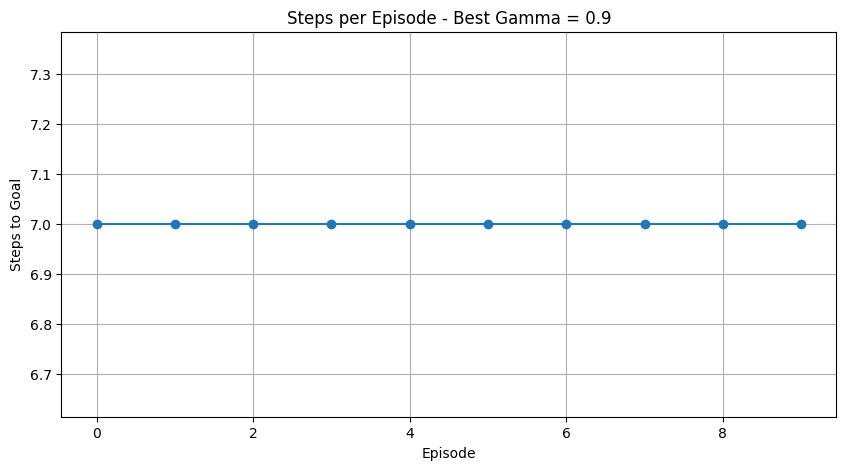

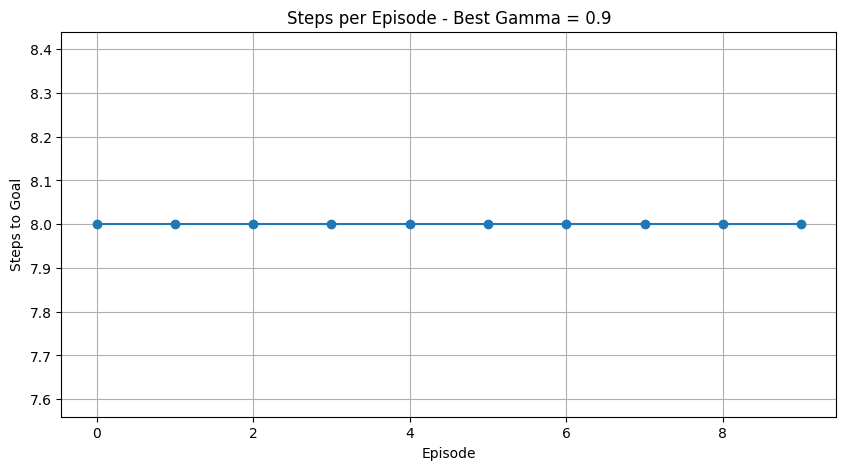

In [38]:
_, _, _, best_steps_list = evaluate_Q(best_Q)

plt.figure(figsize=(10,5))
plt.plot(best_steps_list, marker='o')  # Plot number of steps per episode
plt.xlabel("Episode")
plt.ylabel("Steps to Goal")
plt.title(f"Steps per Episode - Best Gamma = {best_gamma}")
plt.grid()
plt.show()


_, _, rewards_list,_ = evaluate_Q(best_Q)

plt.figure(figsize=(10,5))
plt.plot(rewards_list, marker='o')  # Plot number of steps per episode
plt.xlabel("Episode")
plt.ylabel("Steps to Goal")
plt.title(f"Steps per Episode - Best Gamma = {best_gamma}")
plt.grid()
plt.show()


In [40]:
epsilon_decay_list = [0.90, 0.65, 0.55]
Q_tables_epsilon = {}
num_episodes = 1000
epsilon_start = 1.0
epsilon_min = 0.1
#epsilon_decay = 0.95
alpha = 0.1
gamma = 0.90

for current_epsilon_decay_val in epsilon_decay_list:
    print(f"\nTraining with Epsilon decay = {current_epsilon_decay_val}")

    env = GridEnvironment()  # Reset environment
    Q = np.zeros((env.observation_space.n, env.action_space.n))  # Reset Q-table
    epsilon = epsilon_start

    def epsilon_greedy_policy(state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.choice(env.action_space.n)
        else:
            return np.argmax(Q[state])

    for ep in range(num_episodes):
        obs, info = env.reset()
        total_reward = 0
        reached_goal = False

        state = env.agent_pos[0] * 5 + env.agent_pos[1]
        action = epsilon_greedy_policy(state, epsilon)

        for t in range(env.max_timesteps):
            next_obs, reward, terminated, truncated, info, agent_pos = env.step(action)
            next_state = env.agent_pos[0] * 5 + env.agent_pos[1]
            next_action = epsilon_greedy_policy(next_state, epsilon)

            # Use current gamma value
            Q[state, action] += alpha * (reward + gamma * Q[next_state, next_action] - Q[state, action])

            state = next_state
            action = next_action

            total_reward += reward
            if np.array_equal(agent_pos, env.goal_pos):
                reached_goal = True
            if terminated:
                break

        epsilon = max(epsilon_min, epsilon * current_epsilon_decay_val)


    #storing the values of Q in dictionary
    Q_tables_epsilon[current_epsilon_decay_val] = Q.copy()

    # Print Q-table after training for current gamma
    print(f"\nQ-table after training with gamma={current_epsilon_decay_val}:\n", Q)



Training with Epsilon decay = 0.9

Q-table after training with gamma=0.9:
 [[-0.2583962   0.38514866  1.96025536  0.05717283]
 [ 2.93978409  1.7936595   3.28911864 -0.05082189]
 [ 4.57838307  3.42057151  2.82044214  1.64983767]
 [ 6.78485134 -0.10049737 -0.50591085  0.28846523]
 [ 5.19947143 -0.16169485  0.26156496 -0.42164503]
 [-1.53841649 -1.15782148  2.26440589 -1.48250988]
 [-1.16168124 -0.65329111  5.42993179 -1.47821854]
 [-1.54583557  2.25754158  6.864493    2.94332773]
 [ 4.76903968  3.86080248  9.44079047  4.35323389]
 [ 7.9077484   2.67926764  5.27690641  6.65394941]
 [-1.30565452 -1.27586354 -1.24417643 -1.36533176]
 [-0.96382728 -0.96018526 -2.71998162 -1.03970565]
 [-0.52469226 -0.4413256   5.20335858 -0.52651813]
 [ 0.73885666  1.20023091  7.84985349 -0.959     ]
 [10.          5.16244986  7.13071633  5.13459562]
 [-1.17171909 -1.11741713 -1.0830084  -1.08363414]
 [-0.97671888 -0.87992855 -0.99349862 -0.82260703]
 [-0.68592465 -1.86910297 -0.10940564 -0.39388754]
 [-0.1

In [41]:
def evaluate_Q(Q, num_episodes=1000):
    rewards_list = []
    steps_list = []
    for ep in range(num_episodes):
        env = GridEnvironment()
        obs, info = env.reset()
        state = env.agent_pos[0] * 5 + env.agent_pos[1]
        total_reward = 0
        steps = 0

        while True:
            action = np.argmax(Q[state])
            next_obs, reward, terminated, truncated, info, agent_pos = env.step(action)
            state = agent_pos[0] * 5 + agent_pos[1]
            total_reward += reward
            steps += 1
            if np.array_equal(agent_pos, env.goal_pos) or terminated:
                break

        rewards_list.append(total_reward)
        steps_list.append(steps)

    avg_reward = np.mean(rewards_list)
    #print(avg_reward)
    avg_steps = np.mean(steps_list)
    return avg_reward, avg_steps, rewards_list, steps_list


In [42]:
best_epsilon = None
best_avg_reward = -np.inf
best_avg_steps = np.inf
best_Q = None

for current_epsilon_decay_val in epsilon_decay_list:
    avg_reward, avg_steps, rewards_list, steps_list = evaluate_Q(Q_tables_epsilon[current_epsilon_decay_val])
    print(f"Episolon decay {current_epsilon_decay_val}: Average Reward = {avg_reward}, Average Steps = {avg_steps}")

    # Choose best epsilon based on highest reward, then lowest steps
    if avg_reward > best_avg_reward or (avg_reward == best_avg_reward and avg_steps < best_avg_steps):
        best_avg_reward = avg_reward
        best_avg_steps = avg_steps
        best_epsilon = current_epsilon_decay_val
        best_Q = Q_tables_epsilon[current_epsilon_decay_val]

Episolon decay 0.9: Average Reward = 8.0, Average Steps = 7.0
Episolon decay 0.65: Average Reward = 8.0, Average Steps = 7.0
Episolon decay 0.55: Average Reward = 8.0, Average Steps = 7.0


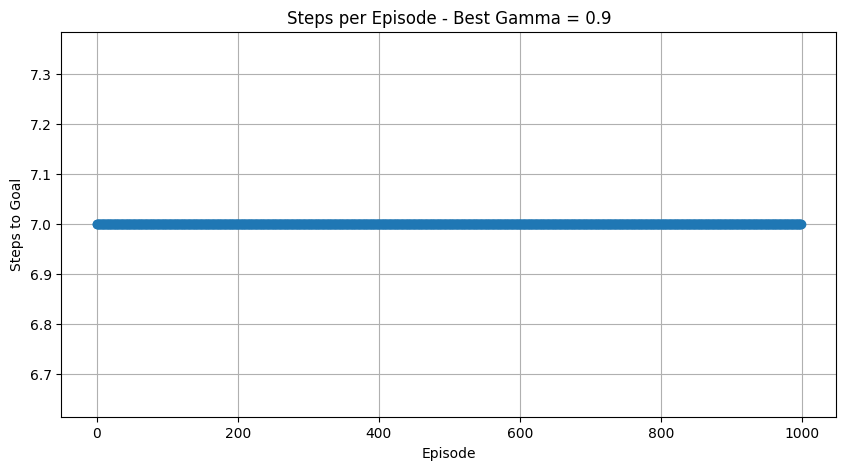

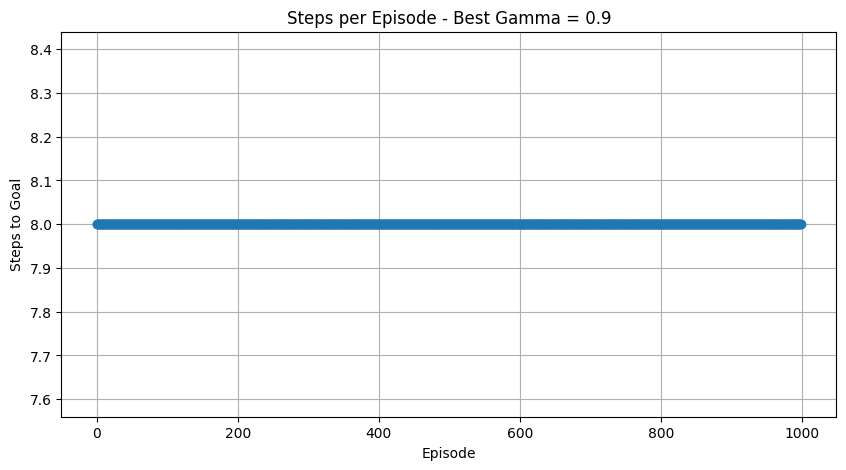

In [43]:
_, _, _, best_steps_list = evaluate_Q(best_Q)

plt.figure(figsize=(10,5))
plt.plot(best_steps_list, marker='o')  # Plot number of steps per episode
plt.xlabel("Episode")
plt.ylabel("Steps to Goal")
plt.title(f"Steps per Episode - Best Gamma = {best_gamma}")
plt.grid()
plt.show()


_, _, rewards_list,_ = evaluate_Q(best_Q)

plt.figure(figsize=(10,5))
plt.plot(rewards_list, marker='o')  # Plot number of steps per episode
plt.xlabel("Episode")
plt.ylabel("Steps to Goal")
plt.title(f"Steps per Episode - Best Gamma = {best_gamma}")
plt.grid()
plt.show()


Evaluation results
- For the hyperparameter tuning i have choosen two parameters
- 1 - Discount factor (gamma)
  In this mainly we have taken values ranging from [0.90, 0.001, 0.02], it basically determines immeditate reward ie 0.001 and the highest gammma value basically determines the futursitic reward . But since in our environment of (4,5) we are getting the reward of 8 . Hence we can see that for small value of 0 we are getting the reward as negative and the number of steps is more

- 2- Epislon decay list

  In this mainly we have taken values ranging from [0.90, 0.65, 0.55], it basically determines greedy way to reach the end goal fast so with 0.55 the agent would stop exploring and pick the best known action. However if we choose the best value that should be ideally 0.9 ie because it has a Slow decay and therefore epsilon stays high for a long time and then we have the possibility of lots of exploration which makes it much more ideal. Since the grid is small and we have less rewards and traps the values for the rewards is not changing much


Contribution Table
| Step | Teammate | Contribution |
|------|-----------|---------------|
| Part 1| Ritik Verma  | 100%|
| Part 2| Abhishek Rajagopalan  | 100% |


Referances: -->

1. https://www.geeksforgeeks.org/machine-learning/what-is-reinforcement-learning/
2. https://www.geeksforgeeks.org/machine-learning/sarsa-reinforcement-learning/
4. https://stats.stackexchange.com/questions/221402/understanding-the-role-of-the-discount-factor-in-reinforcement-learning
5. https://ubuffalo-my.sharepoint.com/personal/avereshc_buffalo_edu/_layouts/15/onedrive.aspx?id=%2Fpersonal%2Favereshc%5Fbuffalo%5Fedu%2FDocuments%2F2025%5FFall%5FRL%2F%5Fpublic%2FCourse%20Materials%2FRL%20Environment%20Visualization&ga=1